<a href="https://colab.research.google.com/github/vikamaslancuk5-commits/E-commerce-Sales-Traffic-Analytics/blob/main/E_commerce_Sales_%26_Traffic_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
import google.auth
from google.cloud import bigquery
import pandas as pd

# 1. Авторизація у Colab
auth.authenticate_user()
credentials, project = google.auth.default()

# 2. Ініціалізація клієнта BigQuery
project_id = 'data-analytics-mate'
client = bigquery.Client(credentials=credentials, project=project_id)

# 3. SQL-запит
query = """
SELECT
    s.date AS session_date,
    s.ga_session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system AS os,
    sp.language AS browser_language,
    sp.name AS traffic_source,
    sp.channel AS traffic_channel,
    a.id AS user_id,
    a.is_verified AS is_email_confirmed,
    a.is_unsubscribed,
    p.category AS category_name,
    p.name AS product_name,
    p.price,
    p.short_description
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
    ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
    ON acs.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
    ON o.item_id = p.item_id
"""

# 4. Вивантаження в DataFrame
df = client.query(query).to_dataframe(create_bqstorage_client=False)

# Збереження у CSV-файл
df.to_csv('ecommerce_dataset.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [ ]:
# 1. Завантаження  датасету
df = pd.read_csv('ecommerce_dataset.csv')

# Конвертація колонки з датою в тип datetime
df['session_date'] = pd.to_datetime(df['session_date'])

print("1. ЗАГАЛЬНА ІНФОРМАЦІЯ ПРО ДАТАСЕТ")
print(f"Загальна кількість рядків: {len(df)}")
print(f"Загальна кількість колонок: {len(df.columns)}")
print(f"Кількість унікальних сесій: {df['ga_session_id'].nunique()}")
print(f"Період даних: від {df['session_date'].min().strftime('%Y-%m-%d')} до {df['session_date'].max().strftime('%Y-%m-%d')}")

print("\n 2. РОЗПОДІЛ КОЛОНОК ЗА ТИПАМИ ДАНИХ")
print (df.info())

print("\n 3. АНАЛІЗ ПРОПУЩЕНИХ ЗНАЧЕНЬ")
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
print(missing_df)

1. ЗАГАЛЬНА ІНФОРМАЦІЯ ПРО ДАТАСЕТ
Загальна кількість рядків: 349545
Загальна кількість колонок: 18
Кількість унікальних сесій: 349545
Період даних: від 2020-11-01 до 2021-01-31

 2. РОЗПОДІЛ КОЛОНОК ЗА ТИПАМИ ДАНИХ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   session_date        349545 non-null  datetime64[ns]
 1   ga_session_id       349545 non-null  int64         
 2   continent           349545 non-null  object        
 3   country             349545 non-null  object        
 4   device              349545 non-null  object        
 5   browser             349545 non-null  object        
 6   device_model        349545 non-null  object        
 7   os                  349545 non-null  object        
 8   browser_language    235279 non-null  object        
 9   traffic_source      349545 non-null  obje

In [ ]:
# Статистика
df.describe()

,session_date,ga_session_id,user_id,is_email_confirmed,is_unsubscribed,price
count,349545,3.495450e+05,27945.000000,27945.000000,27945.000000,33538.000000
mean,2020-12-16 12:42:00.602497536,4.992250e+09,659005.065557,0.716980,0.169440,953.298679
min,2020-11-01 00:00:00,1.205000e+03,636133.000000,0.000000,0.000000,3.000000
25%,2020-11-26 00:00:00,2.493647e+09,647576.000000,0.000000,0.000000,170.000000
50%,2020-12-15 00:00:00,4.988476e+09,658952.000000,1.000000,0.000000,445.000000
75%,2021-01-08 00:00:00,7.491287e+09,670414.000000,1.000000,0.000000,1195.000000
max,2021-01-31 00:00:00,9.999997e+09,681962.000000,1.000000,1.000000,9585.000000
std,NaN,2.887451e+09,13216.529465,0.450474,0.375147,1317.001775


In [ ]:
# Дублікати
df.duplicated().sum()

np.int64(0)

In [ ]:
# 1. Знаходимо всі текстові колонки у датасеті
object_cols = df.select_dtypes(include=['object', 'string']).columns

# 2. Очищаємо від зайвих пробілів та робимо кожне слово з великої літери
df[object_cols] = df[object_cols].apply(lambda col: col.astype(str).str.strip().str.title())

In [ ]:
df.head()

,session_date,ga_session_id,continent,country,device,browser,device_model,os,browser_language,traffic_source,traffic_channel,user_id,is_email_confirmed,is_unsubscribed,category_name,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,Desktop,Chrome,Safari,Macintosh,Zh,<Other>,Paid Search,NaN,NaN,NaN,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"
1,2020-11-01,7115337200,Europe,United Kingdom,Desktop,Chrome,Chrome,Web,En-Us,(Organic),Organic Search,NaN,NaN,NaN,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"
2,2020-11-01,3978035233,Europe,Norway,Mobile,Chrome,<Other>,Web,Zh,(Direct),Direct,NaN,NaN,NaN,Tables & Desks,Råskog,189.0,"Trolley, 35X45X78 Cm"
3,2020-11-01,9648986282,Africa,Nigeria,Mobile,Chrome,<Other>,Android,Es-Es,(Direct),Direct,NaN,NaN,NaN,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"
4,2020-11-01,4393441533,Asia,China,Desktop,Chrome,Chrome,Windows,En-Us,(Direct),Direct,NaN,NaN,NaN,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"



###  Опис датасету

#### 1. Загальна інформація про датасет

* **Загальна кількість рядків:** 349,545


* **Загальна кількість колонок:** 18


* **Кількість унікальних сесій:** 349,545 (кожен рядок відповідає окремій сесії або сесії з замовленням)


* **Аналізований період:** з **2020-11-01** по **2021-01-31** (3 повних місяці)



---

#### 2. Розподіл колонок за типами даних

* **Datetime (1 колонка):** session_date.


* **Числові / Numeric (5 колонок):** ga_session_id, user_id, is_email_confirmed, is_unsubscribed, price.


* **Категоріальні / Categorical (12 колонок):** continent, country, device, browser, device_model, os, browser_language, traffic_source, traffic_channel, category_name, product_name, short_description.



---

#### 3. Аналіз пропущених значень (Nulls) та їх бізнес-причини

Пропущені значення наявні в 8 колонках і мають чітке бізнес-пояснення, зумовлене логікою роботи сайту та типом з'єднань (LEFT JOIN):

1. **user_id (92.01%), is_email_confirmed (92.01%), is_unsubscribed (92.01%):**
* **Причина:** Переважна більшість відвідувачів сайту (понад 92%) є **незареєстрованими користувачами** або здійснюють візит без авторизації. Оскільки при створенні датасету використано LEFT JOIN для збереження усіх сесій, для гостьових візитів дані про акаунт відсутні (NaN).




2. **category_name (90.41%), price (90.41%), product_name (90.41%), short_description (90.41%):**
* **Причина:** Пропусками позначені сесії, під час яких відвідувачі не здійснили покупку або не переглядали конкретний товар. Показник конверсії сесій у замовлення становить близько 9.59%, що є природним і типовим показником для сфери e-commerce.




3. **browser_language (32.69%):**
* **Причина:** Частина користувачів або їхні браузери (наприклад, при блокуванні трекерів чи використанні приватних режимів) не передають мовні налаштування в систему аналітики.

#**Visualization**

/tmp/ipykernel_1008/3739138955.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/3739138955.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/3739138955.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/3739138955.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


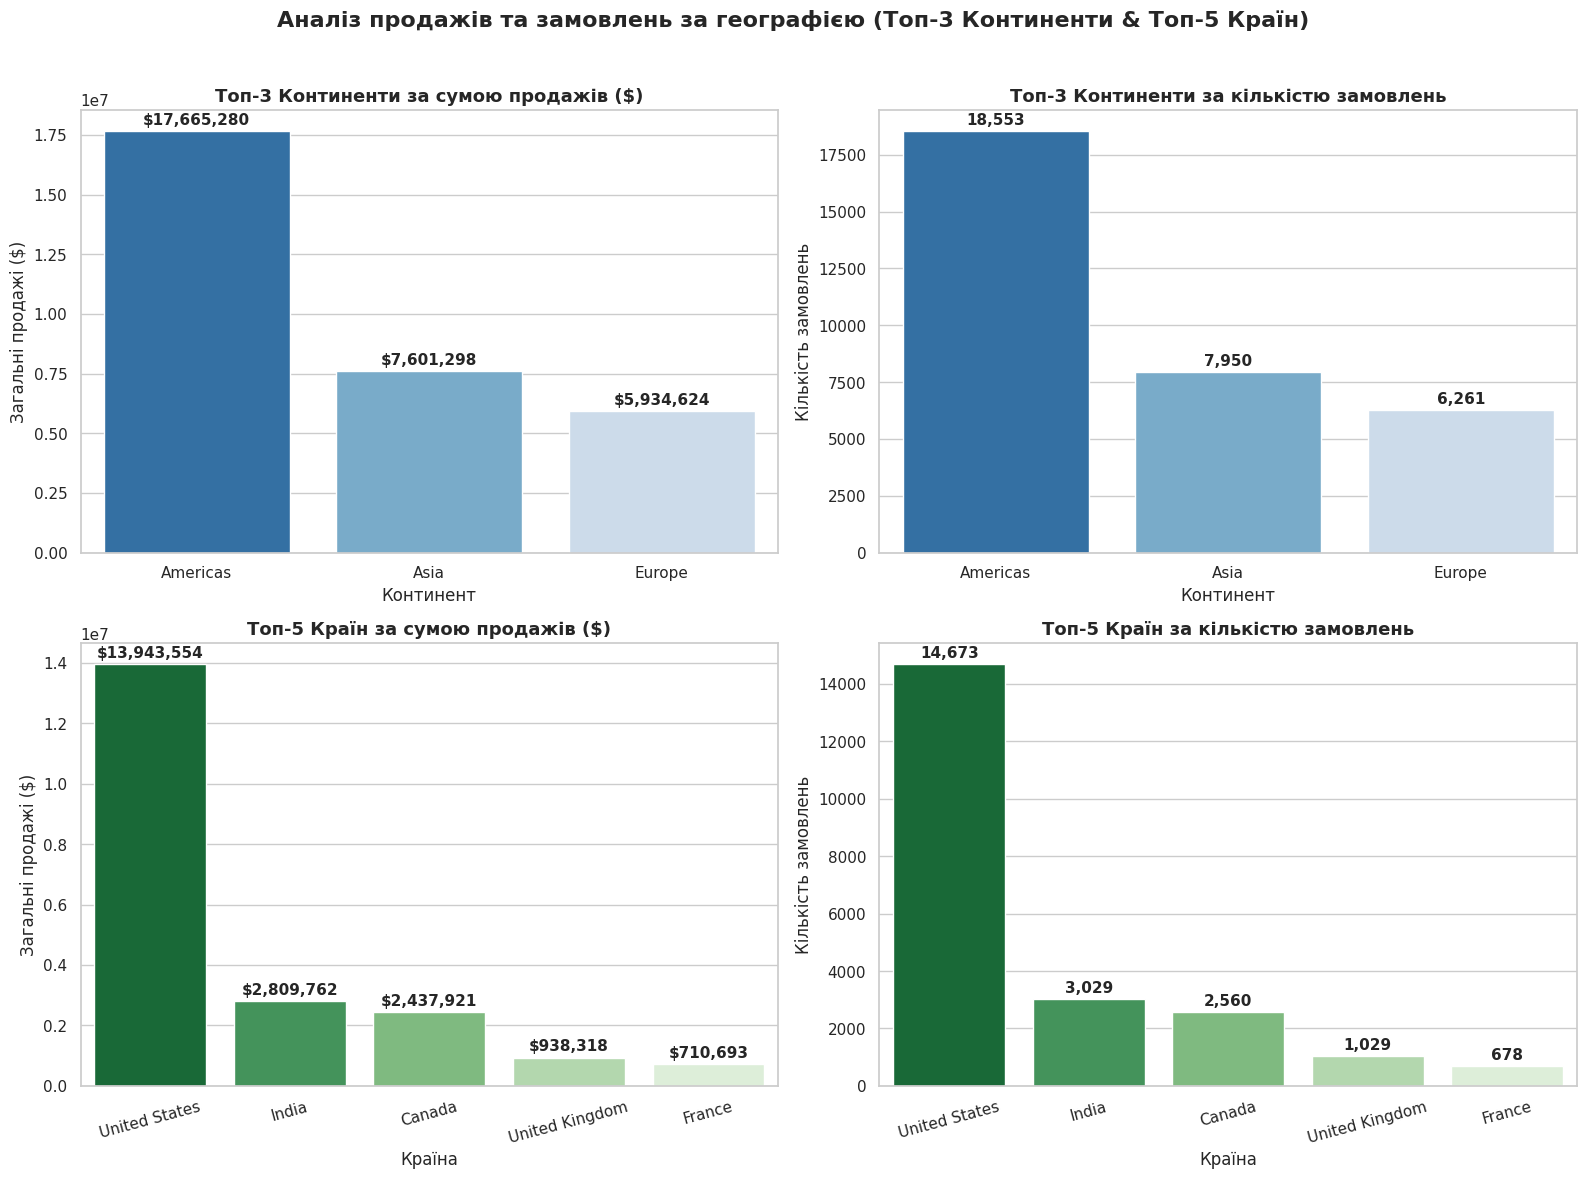

In [ ]:
# Cесії, де було здійснено покупку
sales_df = df.dropna(subset=['price']).copy()

# Топ-3 континентів
continents_sales = sales_df.groupby('continent').agg(
    total_sales=('price', 'sum'),
    orders_count=('ga_session_id', 'count')
).reset_index()

top_3_continents_sales = continents_sales.sort_values(by='total_sales', ascending=False).head(3)
top_3_continents_orders = continents_sales.sort_values(by='orders_count', ascending=False).head(3)

# Топ-5 країн
countries_sales = sales_df.groupby('country').agg(
    total_sales=('price', 'sum'),
    orders_count=('ga_session_id', 'count')
).reset_index()

top_5_countries_sales = countries_sales.sort_values(by='total_sales', ascending=False).head(5)
top_5_countries_orders = countries_sales.sort_values(by='orders_count', ascending=False).head(5)

# Будуємо графіки

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Аналіз продажів та замовлень за географією (Топ-3 Континенти & Топ-5 Країн)', fontsize=16, fontweight='bold')

# Графік 1: Топ-3 континенти за продажами
sns.barplot(
    data=top_3_continents_sales, x='continent', y='total_sales',
    ax=axes[0, 0], palette='Blues_r'
)
axes[0, 0].set_title('Топ-3 Континенти за сумою продажів ($)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Континент')
axes[0, 0].set_ylabel('Загальні продажі ($)')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Графік 2: Топ-3 континенти за кількістю замовлень
sns.barplot(
    data=top_3_continents_orders, x='continent', y='orders_count',
    ax=axes[0, 1], palette='Blues_r'
)
axes[0, 1].set_title('Топ-3 Континенти за кількістю замовлень', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Континент')
axes[0, 1].set_ylabel('Кількість замовлень')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Графік 3: Топ-5 країн за продажами
sns.barplot(
    data=top_5_countries_sales, x='country', y='total_sales',
    ax=axes[1, 0], palette='Greens_r'
)
axes[1, 0].set_title('Топ-5 Країн за сумою продажів ($)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Країна')
axes[1, 0].set_ylabel('Загальні продажі ($)')
axes[1, 0].tick_params(axis='x', rotation=15)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Графік 4: Топ-5 країн за кількістю замовлень
sns.barplot(
    data=top_5_countries_orders, x='country', y='orders_count',
    ax=axes[1, 1], palette='Greens_r'
)
axes[1, 1].set_title('Топ-5 Країн за кількістю замовлень', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Країна')
axes[1, 1].set_ylabel('Кількість замовлень')
axes[1, 1].tick_params(axis='x', rotation=15)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/tmp/ipykernel_1008/2546918704.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


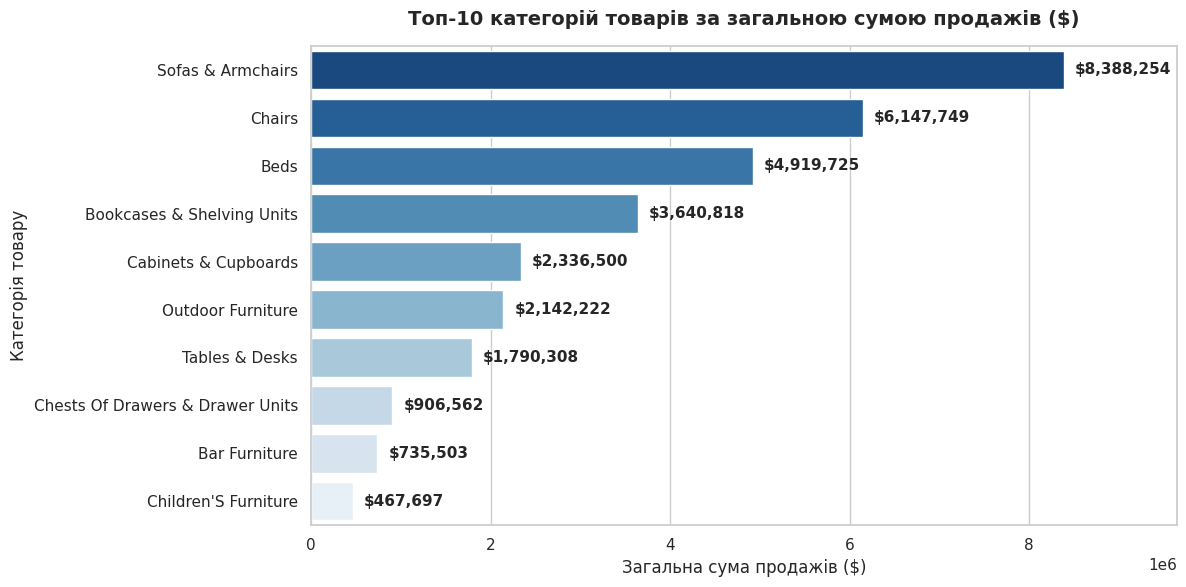

In [ ]:
# 1. Лише сесії з покупками
sales_df = df.dropna(subset=['price']).copy()

# 2. Групуємо за категорією та рахуємо загальну суму продажів
top_10_categories = (
    sales_df.groupby('category_name')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'total_sales'})
    .sort_values(by='total_sales', ascending=False)
    .head(10)
)

# 3. Візуалізація
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=top_10_categories,
    x='total_sales',
    y='category_name',
    palette='Blues_r'
)

# Додаємо числові значення в кінці кожного стовпчика
for p in barplot.patches:
    width = p.get_width()
    barplot.annotate(
        f'${width:,.0f}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(8, 0), textcoords='offset points',
        fontweight='bold'
    )

plt.title('Топ-10 категорій товарів за загальною сумою продажів ($)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Загальна сума продажів ($)', fontsize=12)
plt.ylabel('Категорія товару', fontsize=12)
plt.xlim(0, top_10_categories['total_sales'].max() * 1.15) # Додаємо відступ для тексту підписів
plt.tight_layout()
plt.show()

/tmp/ipykernel_1008/2498307319.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=global_top10, x='global_sales', y='category_name', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_1008/2498307319.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_top10, x='country_sales', y='category_name', ax=axes[1], palette='Greens_r')


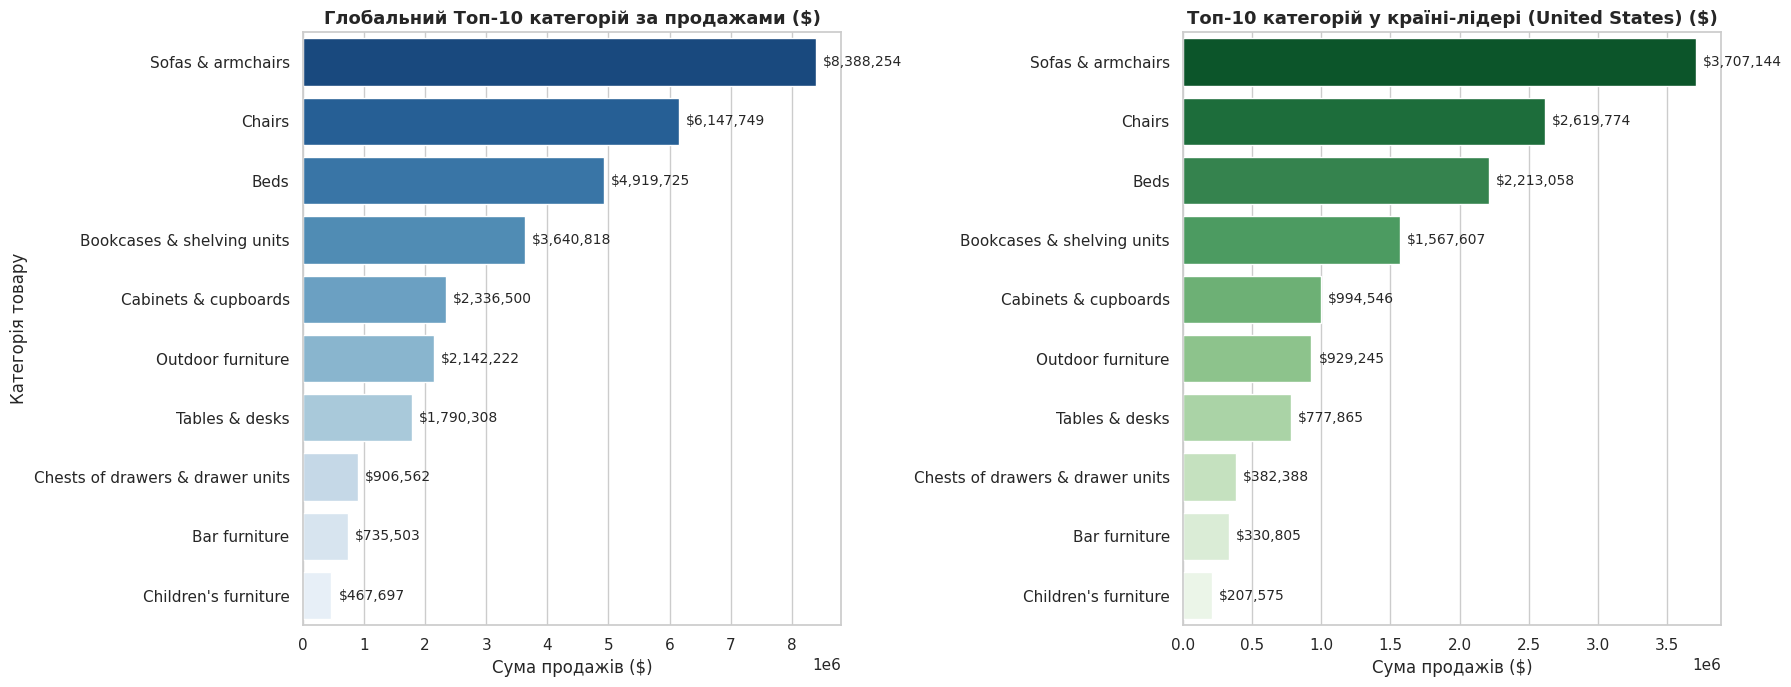

In [ ]:
# Лише сесії з покупками
sales_df = df.dropna(subset=['price']).copy()

# 1. Визначення країни-лідера та розрахунок топу
top_country = sales_df.groupby('country')['price'].sum().idxmax()

global_top10 = (
    sales_df.groupby('category_name')['price']
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={'price': 'global_sales'})
)

country_top10 = (
    sales_df[sales_df['country'] == top_country]
    .groupby('category_name')['price']
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={'price': 'country_sales'})
)

# 2. Побудова графіків
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Графік 1: Глобальний Топ-10
sns.barplot(data=global_top10, x='global_sales', y='category_name', ax=axes[0], palette='Blues_r')
axes[0].set_title('Глобальний Топ-10 категорій за продажами ($)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Сума продажів ($)')
axes[0].set_ylabel('Категорія товару')
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Графік 2: Топ-10 у країні-лідері
sns.barplot(data=country_top10, x='country_sales', y='category_name', ax=axes[1], palette='Greens_r')
axes[1].set_title(f'Топ-10 категорій у країні-лідері ({top_country}) ($)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Сума продажів ($)')
axes[1].set_ylabel('')
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1008/1068392503.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/1068392503.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


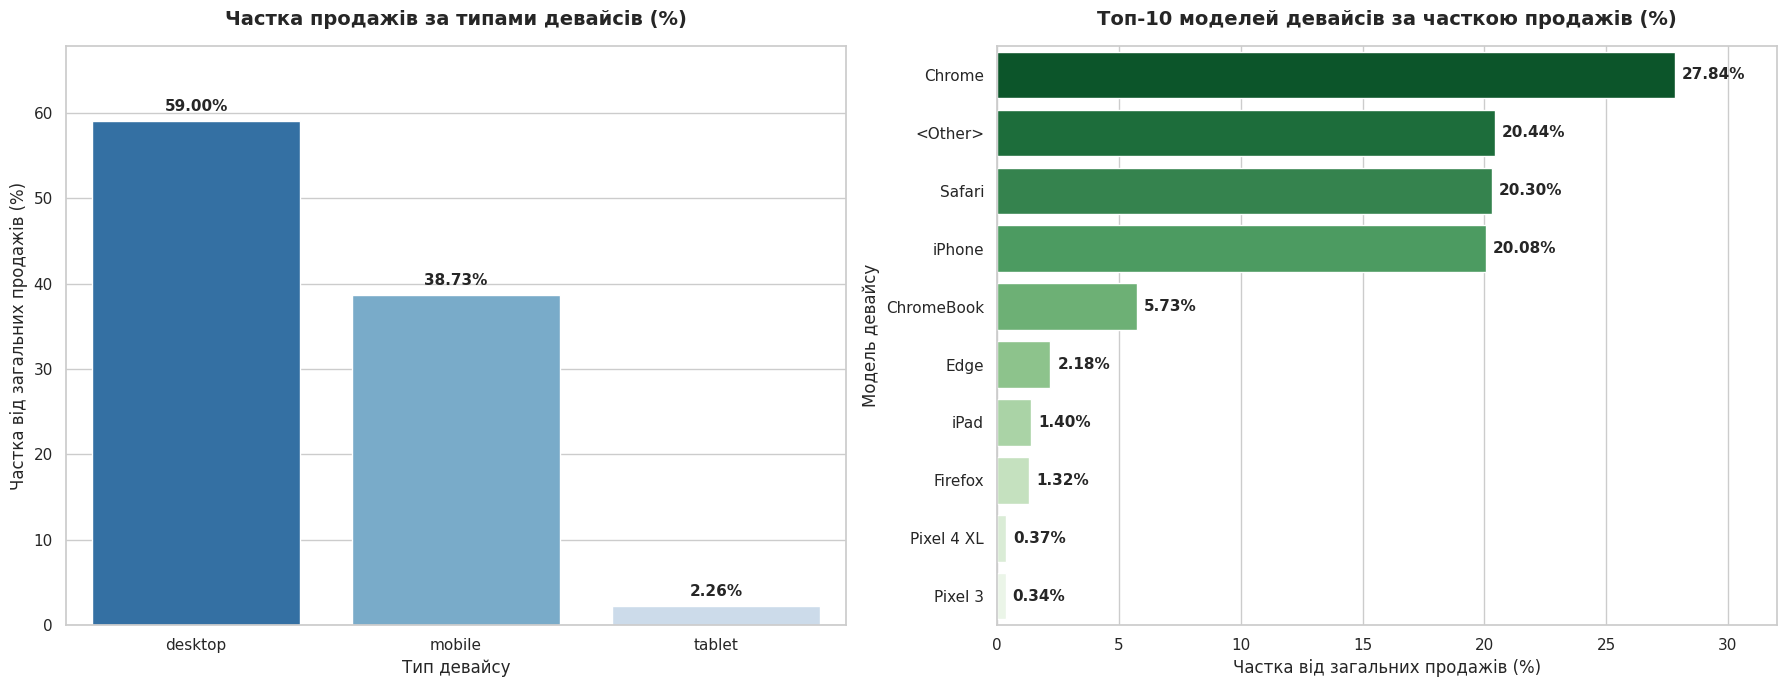

In [ ]:
# Фільтруємо лише сесії з покупками
sales_df = df.dropna(subset=['price']).copy()
total_revenue = sales_df['price'].sum()

# 1. Аналіз за типами девайсів

device_sales = (
    sales_df.groupby('device')['price']
    .sum()
    .reset_index()
)
device_sales['share_%'] = (device_sales['price'] / total_revenue * 100).round(2)
device_sales = device_sales.sort_values(by='price', ascending=False)


# 2. Аналіз за моделями девайсів

model_sales = (
    sales_df.groupby('device_model')['price']
    .sum()
    .reset_index()
)
model_sales['share_%'] = (model_sales['price'] / total_revenue * 100).round(2)
top10_models = model_sales.sort_values(by='price', ascending=False).head(10)

# 3. Візуалізація

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Графік 1: Продажі за типами девайсів
sns.barplot(
    data=device_sales, x='device', y='share_%',
    ax=axes[0], palette='Blues_r'
)
axes[0].set_title('Частка продажів за типами девайсів (%)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Тип девайсу', fontsize=12)
axes[0].set_ylabel('Частка від загальних продажів (%)', fontsize=12)
axes[0].set_ylim(0, device_sales['share_%'].max() * 1.15)

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        f'{height:.2f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontweight='bold'
    )

# Графік 2: Топ-10 моделей девайсів за часткою продажів
sns.barplot(
    data=top10_models, x='share_%', y='device_model',
    ax=axes[1], palette='Greens_r'
)
axes[1].set_title('Топ-10 моделей девайсів за часткою продажів (%)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Частка від загальних продажів (%)', fontsize=12)
axes[1].set_ylabel('Модель девайсу', fontsize=12)
axes[1].set_xlim(0, top10_models['share_%'].max() * 1.15)

for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(
        f'{width:.2f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0), textcoords='offset points',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

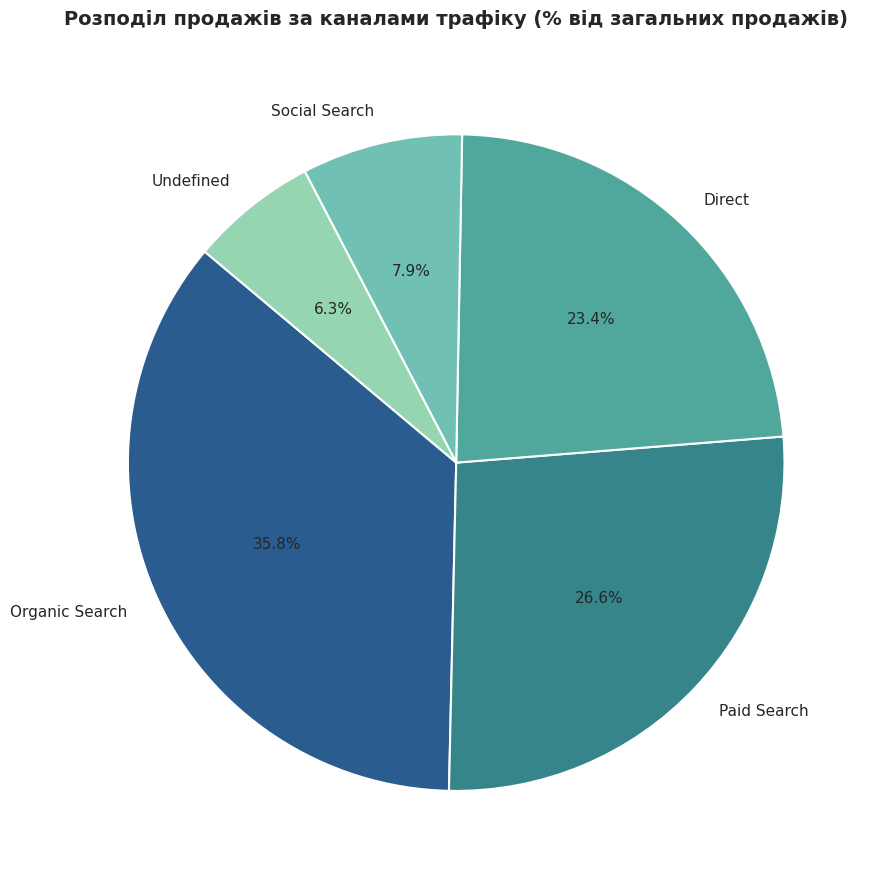

In [ ]:
# Лише сесії з покупками
sales_df = df.dropna(subset=['price']).copy()

# Агрегація продажів за каналами трафіку
channel_sales = (
    sales_df.groupby('traffic_channel')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'total_sales'})
    .sort_values(by='total_sales', ascending=False)
)

colors = ['#2b5c8f', '#36858b', '#4fa89b', '#70c1b3', '#95d5b2', '#b7e4c7', '#d8f3dc', '#a8dadc']

# Візуалізація
plt.figure(figsize=(9, 9))
plt.pie(
    channel_sales['total_sales'],
    labels=channel_sales['traffic_channel'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(channel_sales)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)

plt.title('Розподіл продажів за каналами трафіку (% від загальних продажів)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

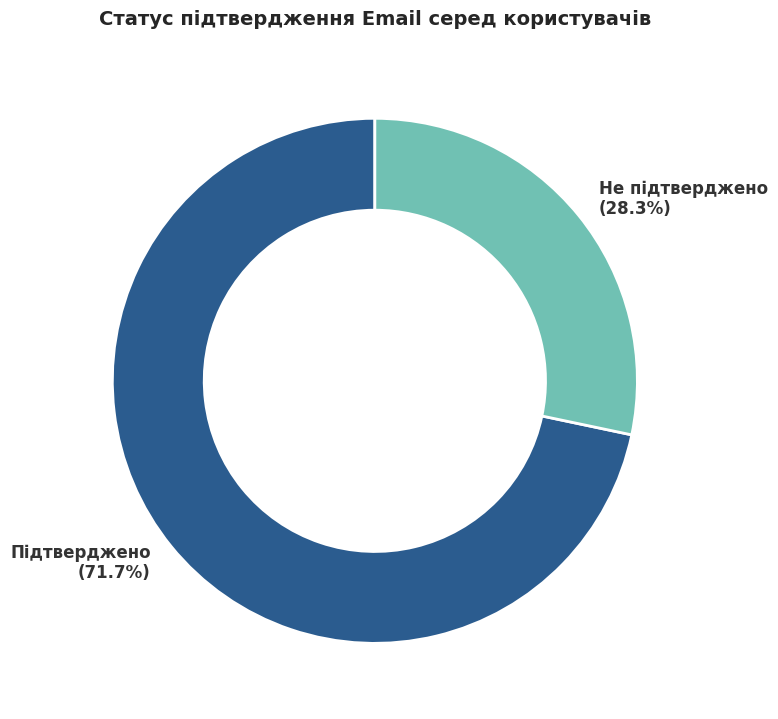

In [ ]:
# 1. Дані
confirmed_pct = 71.7
not_confirmed_pct = 28.3

# Формуємо підписи по боках із відсотками
labels = [
    f'Підтверджено\n({confirmed_pct:.1f}%)',
    f'Не підтверджено\n({not_confirmed_pct:.1f}%)'
]
sizes = [confirmed_pct, not_confirmed_pct]
colors = ['#2b5c8f', '#70c1b3']

fig, ax = plt.subplots(figsize=(8, 8))

# 2. Побудова діаграми
wedges, texts = ax.pie(
    sizes,
    labels=labels,
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12, color='#333333', fontweight='bold')
)

# 3. Налаштування заголовка
ax.set_title('Статус підтвердження Email серед користувачів', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

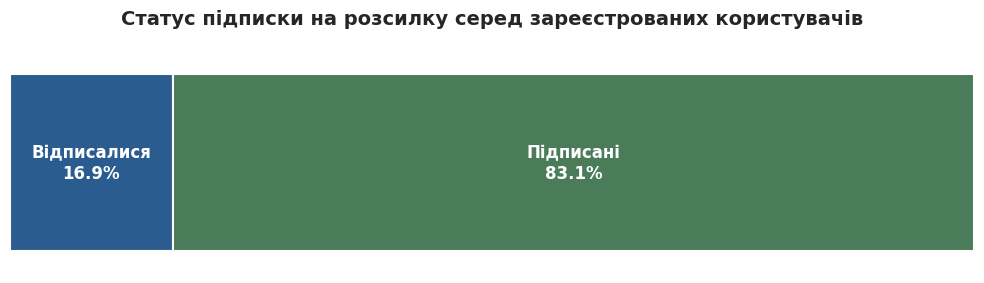

In [ ]:
# Дані
subscribed_pct = 83.1
unsubscribed_pct = 16.9

fig, ax = plt.subplots(figsize=(10, 3))

# 1. Побудова діаграми
# Перший сегмент: Відписалися (синій колір)
ax.barh(0, unsubscribed_pct, color='#2b5c8f', edgecolor='white', linewidth=1.5)

# Другий сегмент: Підписані (зелений колір)
ax.barh(0, subscribed_pct, left=unsubscribed_pct, color='#4a7c59', edgecolor='white', linewidth=1.5)

# 2. Додавання підписів всередині блоків
ax.text(unsubscribed_pct / 2, 0, f'Відписалися\n{unsubscribed_pct:.1f}%',
        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

ax.text(unsubscribed_pct + (subscribed_pct / 2), 0, f'Підписані\n{subscribed_pct:.1f}%',
        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 3. Налаштування осей та приховування рамок
ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)
ax.axis('off')

# Заголовок
plt.title('Статус підписки на розсилку серед зареєстрованих користувачів',
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1008/4237836219.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/4237836219.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/4237836219.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1008/4237836219.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


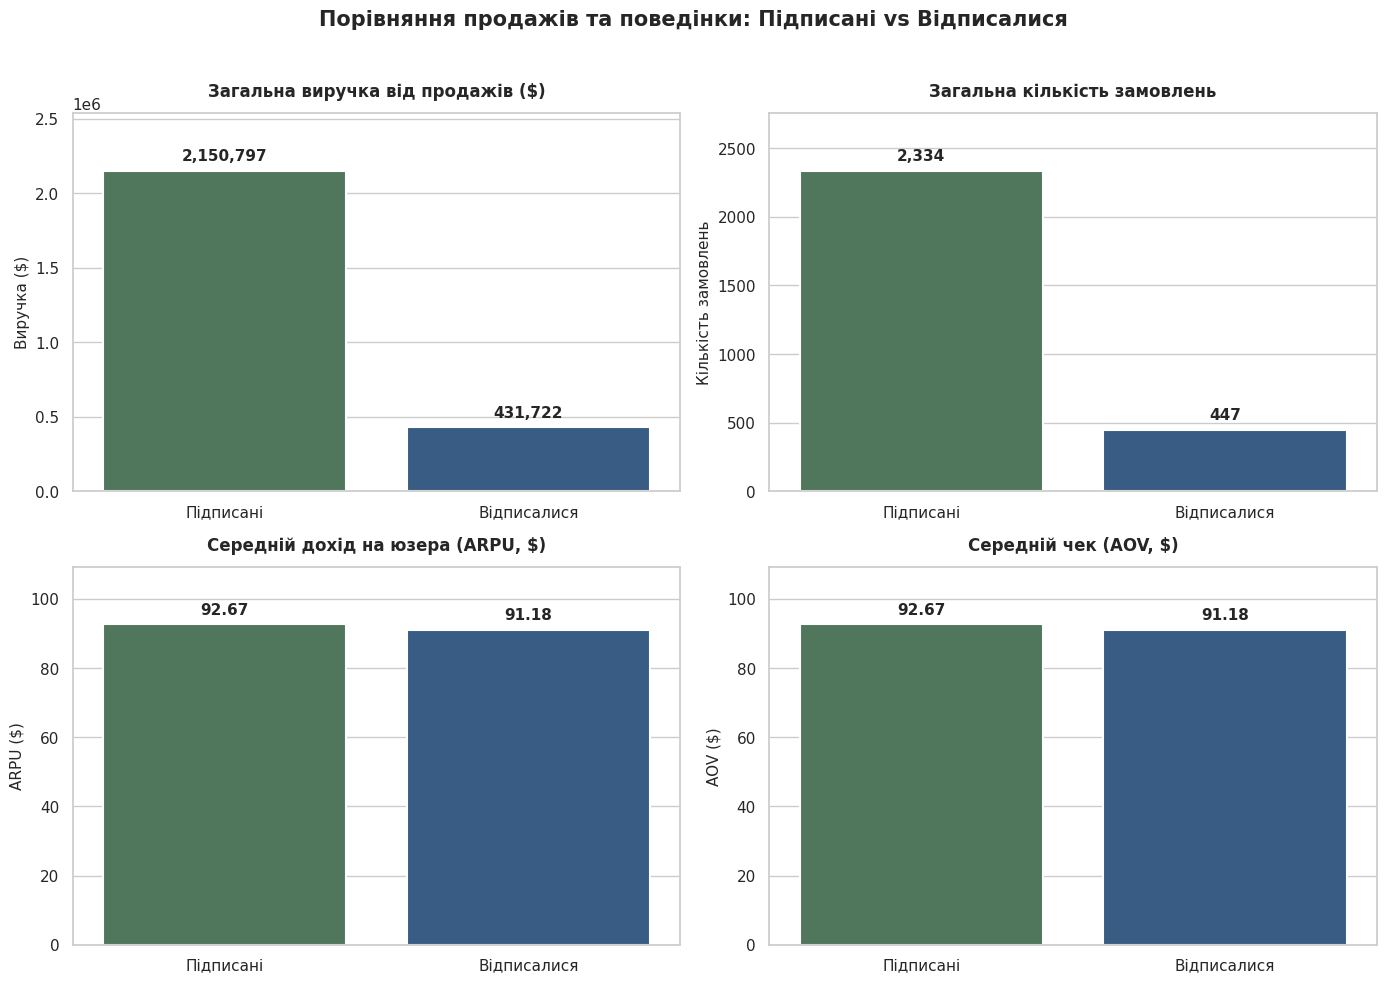

In [ ]:
# 1. Підготовка даних на рівні унікальних користувачів
registered_df = df.dropna(subset=['user_id']).copy()

user_summary = registered_df.groupby('user_id').agg(
    is_unsubscribed=('is_unsubscribed', 'first'),
    total_revenue=('price', 'sum'),
    orders_count=('price', lambda x: x.notnull().sum())
).reset_index()

# Обчислення AOV
user_summary['aov'] = (user_summary['total_revenue'] / user_summary['orders_count']).fillna(0)

# 2. Агрегація підсумкових метрик за групами
group_metrics = user_summary.groupby('is_unsubscribed').agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('orders_count', 'sum'),
    arpu=('total_revenue', 'mean'),
    aov=('aov', 'mean')
).reset_index()

# Позначення груп та кольорів
group_metrics['Group'] = group_metrics['is_unsubscribed'].map({0: 'Підписані', 1: 'Відписалися'})
palette = {'Підписані': '#4a7c59', 'Відписалися': '#2b5c8f'}

# 3. Побудова сітки
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_config = [
    ('total_revenue', 'Загальна виручка від продажів ($)', 'Виручка ($)', '{:,.0f}', axes[0, 0]),
    ('total_orders', 'Загальна кількість замовлень', 'Кількість замовлень', '{:,.0f}', axes[0, 1]),
    ('arpu', 'Середній дохід на юзера (ARPU, $)', 'ARPU ($)', '{:.2f}', axes[1, 0]),
    ('aov', 'Середній чек (AOV, $)', 'AOV ($)', '{:.2f}', axes[1, 1])
]

for col, title, ylabel, fmt, ax in metrics_config:
    sns.barplot(
        data=group_metrics,
        x='Group',
        y=col,
        palette=palette,
        ax=ax,
        edgecolor='white',
        linewidth=1.5
    )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, group_metrics[col].max() * 1.18)

    # Додавання підписів значень
    for p in ax.patches:
        height = p.get_height()
        val_str = fmt.format(height)
        ax.annotate(
            val_str,
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 5), textcoords='offset points',
            fontweight='bold', fontsize=11
        )

plt.suptitle('Порівняння продажів та поведінки: Підписані vs Відписалися', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/tmp/ipykernel_1008/1207877882.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


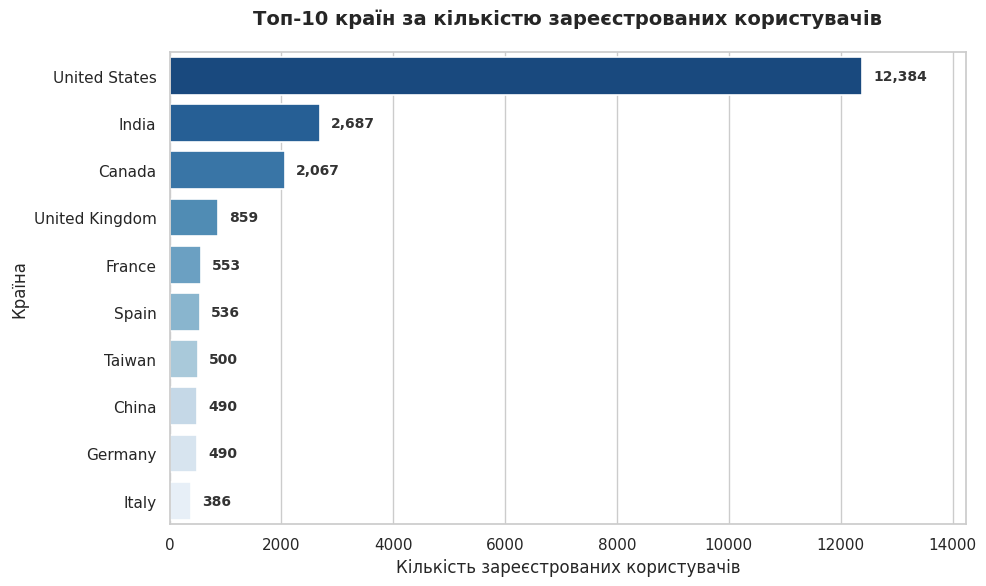

In [ ]:
# 1. Відбираємо лише зареєстрованих користувачів та видаляємо дублікати
registered_users = (
    df.dropna(subset=['user_id'])
    .drop_duplicates(subset=['user_id'])
    .copy()
)

# 2. Групування за країнами та підрахунок унікальних користувачів
users_by_country = (
    registered_users.groupby('country')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'registered_users_count'})
    .sort_values(by='registered_users_count', ascending=False)
)

# Топ-10 країн за реєстраціями
top_countries = users_by_country.head(10)

# 3. Візуалізація
plt.figure(figsize=(10, 6))

barplot = sns.barplot(
    data=top_countries,
    x='registered_users_count',
    y='country',
    palette='Blues_r',
    edgecolor='white',
    linewidth=1.2
)

for p in barplot.patches:
    width = p.get_width()
    barplot.annotate(
        f'{int(width):,}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(8, 0), textcoords='offset points',
        fontweight='bold', fontsize=10, color='#333333'
    )

plt.title('Топ-10 країн за кількістю зареєстрованих користувачів', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Кількість зареєстрованих користувачів', fontsize=12)
plt.ylabel('Країна', fontsize=12)
plt.xlim(0, top_countries['registered_users_count'].max() * 1.15)

plt.tight_layout()
plt.show()


#**Аналіз динаміки продажів**

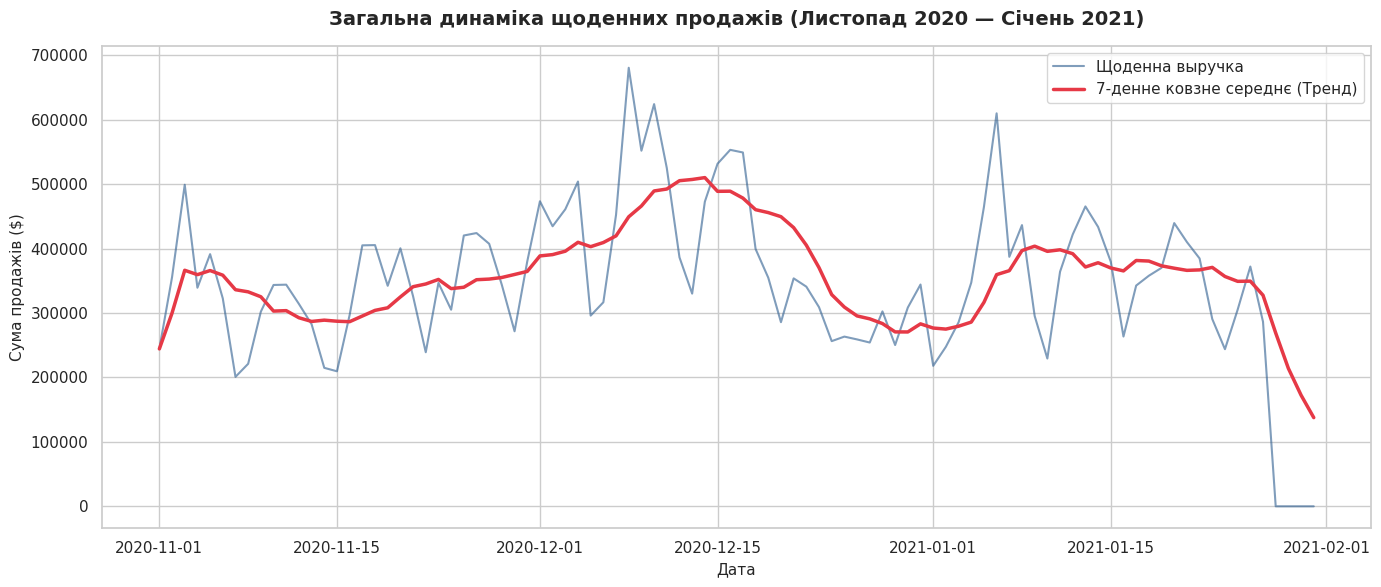

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю візуалізації
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Переконуємось, що дата має правильний тип datetime
df['session_date'] = pd.to_datetime(df['session_date'])

# 1. Розрахунок загальних продажів за кожну дату
daily_sales = df.groupby('session_date')['price'].sum().reset_index()
daily_sales.rename(columns={'session_date': 'Дата', 'price': 'Сума продажів ($)'}, inplace=True)

# Обчислення 7-денного ковзного середнього для виявлення тренду
daily_sales['7d_rolling_avg'] = daily_sales['Сума продажів ($)'].rolling(window=7, min_periods=1).mean()


# 2. Візуалізація загальної динаміки продажів
plt.figure(figsize=(14, 6))

# Лінія щоденних продажів
plt.plot(
    daily_sales['Дата'],
    daily_sales['Сума продажів ($)'],
    label='Щоденна выручка',
    color='#2b5c8f',
    alpha=0.6,
    linewidth=1.5
)

# Лінія тренду (7-денне ковзне середнє)
plt.plot(
    daily_sales['Дата'],
    daily_sales['7d_rolling_avg'],
    label='7-денне ковзне середнє (Тренд)',
    color='#e63946',
    linewidth=2.5
)

plt.title('Загальна динаміка щоденних продажів (Листопад 2020 — Січень 2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Сума продажів ($)', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

**Сезонність**

Тижнева сезонність: Чітко виражена циклічність — піки продажів припадають на робочі дні (вівторок–четвер), а спади — на вихідні.

Святкові піки: Найвищі рівні виручки зафіксовані наприкінці листопада та передсвяткових закупів у грудні.

Січневий тренд: Очікуване спадання купівельної спроможності після свят із вирівнюванням тренду.

=== ПІДСУМКОВА СТАТИСТИКА ПРОДАЖІВ ЗА КОНТИНЕНТАМИ ===
           total_revenue  orders_count  avg_order_value  revenue_share (%)
continent                                                                 
Americas      17665280.0         18553           952.15              56.62
Asia           7601298.3          7950           956.14              24.36
Europe         5934624.2          6261           947.87              19.02




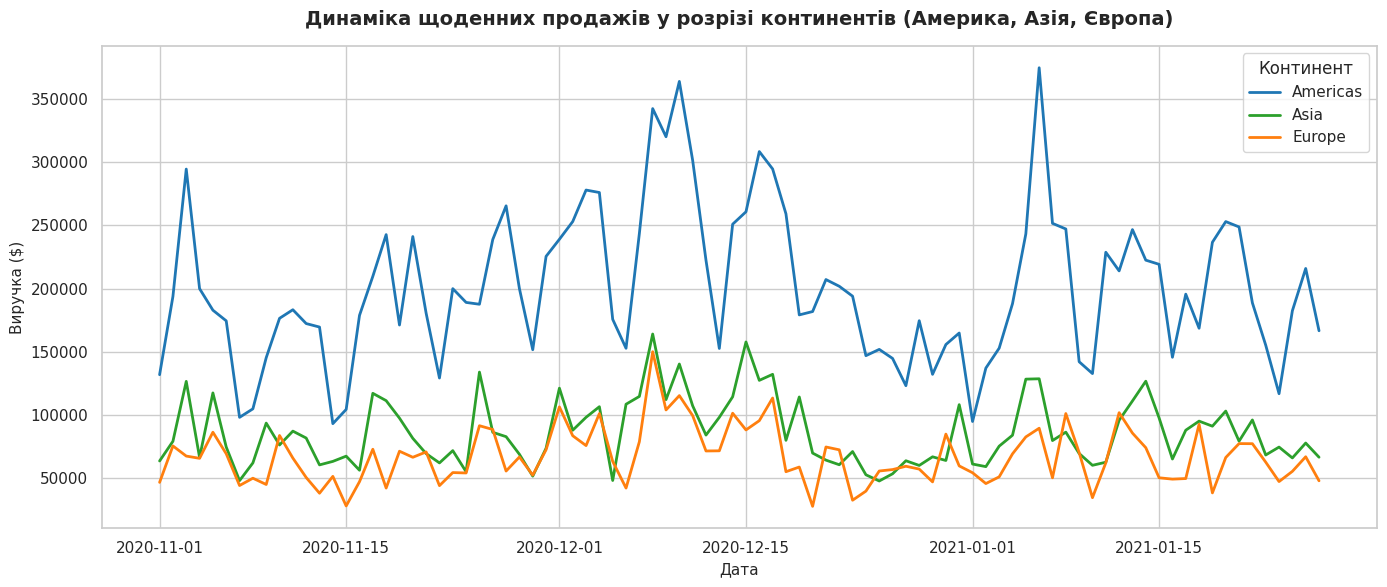

In [ ]:
# Переконуємось, що session_date має тип datetime
df['session_date'] = pd.to_datetime(df['session_date'])

# 1. Фільтрація даних для трьох цільових континентів
target_continents = ['Americas', 'Asia', 'Europe']
cont_df = df[df['continent'].isin(target_continents) & df['price'].notnull()].copy()

# 2. Розрахунок щоденних продажів за континентами
daily_cont_sales = cont_df.groupby(['session_date', 'continent'])['price'].sum().reset_index()

# 3. Підсумкова статистика за період для аналізу
summary_sales = cont_df.groupby('continent').agg(
    total_revenue=('price', 'sum'),
    orders_count=('ga_session_id', 'count'),
    avg_order_value=('price', 'mean')
).loc[target_continents]

summary_sales['revenue_share (%)'] = (summary_sales['total_revenue'] / summary_sales['total_revenue'].sum() * 100).round(2)

print(" ПІДСУМКОВА СТАТИСТИКА ПРОДАЖІВ ЗА КОНТИНЕНТАМИ")
print(summary_sales.round(2))
print("\n" + "="*60 + "\n")

# 4. Побудова графіку
plt.figure(figsize=(14, 6))

# Кольори
palette = {
    'Americas': '#1f77b4',
    'Asia': '#2ca02c',
    'Europe': '#ff7f0e'
}

sns.lineplot(
    data=daily_cont_sales,
    x='session_date',
    y='price',
    hue='continent',
    palette=palette,
    linewidth=2
)

plt.title('Динаміка щоденних продажів у розрізі континентів (Америка, Азія, Європа)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Виручка ($)', fontsize=11)
plt.legend(title='Континент', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

Динаміка по всіх трьох континентах відображає спільну тенденцію: зростання в листопаді–грудні та природне вирівнювання попиту у січні після святкового періоду.

ПІДСУМКОВА СТАТИСТИКА ПРОДАЖІВ ЗА КАНАЛАМИ ТРАФІКУ
                 total_revenue  orders_count  revenue_share (%)
traffic_channel                                                
Organic Search      11433151.6         11921              35.76
Paid Search          8511049.4          9042              26.62
Direct               7494923.4          7800              23.44
Social Search        2532105.7          2716               7.92
Undefined            2000501.0          2059               6.26




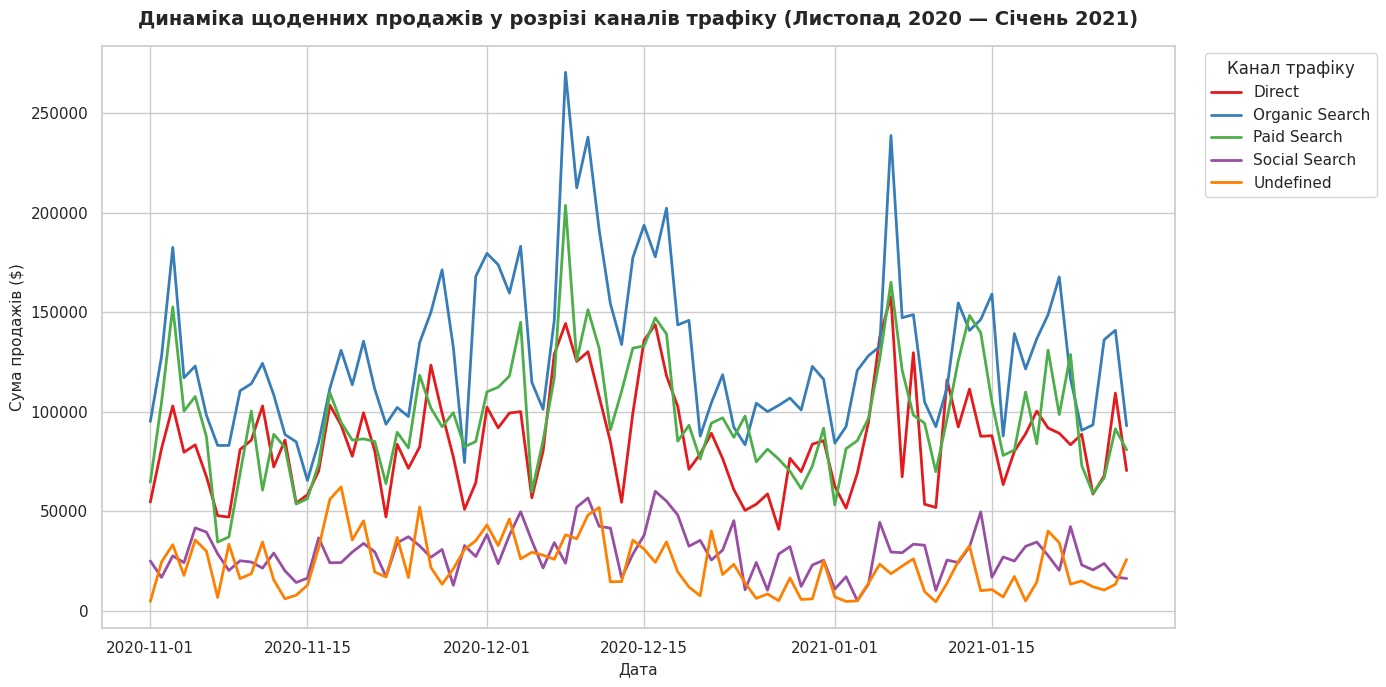

In [ ]:
# 1. Фільтрація лише тих сесій, де відбулися покупки
sales_df = df.dropna(subset=['price']).copy()

# 2. Розрахунок щоденних продажів за каналами трафіку
daily_channel_sales = sales_df.groupby(['session_date', 'traffic_channel'])['price'].sum().reset_index()

# 3. Підсумкова статистика за період
channel_summary = sales_df.groupby('traffic_channel').agg(
    total_revenue=('price', 'sum'),
    orders_count=('ga_session_id', 'count')
).sort_values(by='total_revenue', ascending=False)

channel_summary['revenue_share (%)'] = (channel_summary['total_revenue'] / channel_summary['total_revenue'].sum() * 100).round(2)

print("ПІДСУМКОВА СТАТИСТИКА ПРОДАЖІВ ЗА КАНАЛАМИ ТРАФІКУ")
print(channel_summary)
print("\n" + "="*60 + "\n")

# 4. Побудова графіку динаміки продажів
plt.figure(figsize=(14, 7))
palette = sns.color_palette("Set1", n_colors=daily_channel_sales['traffic_channel'].nunique())

sns.lineplot(
    data=daily_channel_sales,
    x='session_date',
    y='price',
    hue='traffic_channel',
    palette=palette,
    linewidth=2
)

plt.title('Динаміка щоденних продажів у розрізі каналів трафіку (Листопад 2020 — Січень 2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Сума продажів ($)', fontsize=11)
plt.legend(title='Канал трафіку', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

**Канали-лідери продажів** :Organic Search та Direct генерують найбільший обсяг щоденної виручки.Саме ці канали відповідають за основні піки продажів у кінці листопада та передсвяткових закупів у грудні.   

**Синхронність тижневої сезонності** : усі ключові канали трафіку одночасно демонструють тижневу циклічність: спади виручки у вихідні дні та піки у робочі дні.   

**Платний та допоміжний трафік** (Paid Search, Referral, Display): плата за рекламу та реферальний трафік демонструють більш згладжену та стабільну динаміку протягом усього періоду без екстремальних сплесків.

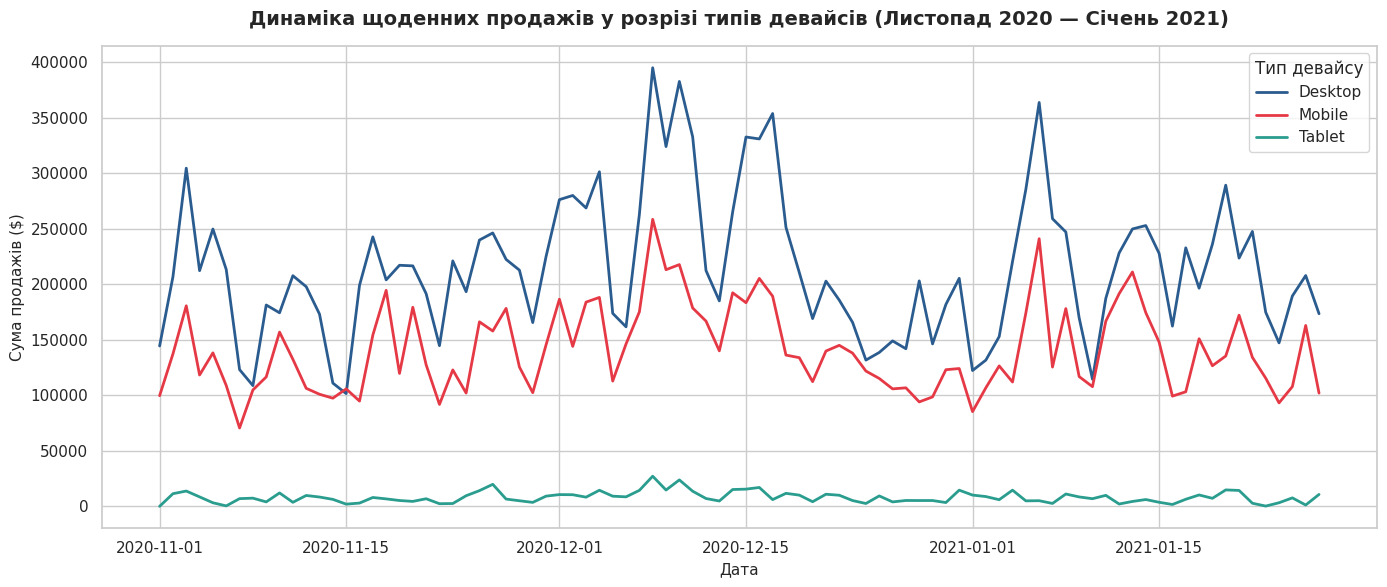

In [ ]:
# 1. Фільтрація транзакцій
sales_df = df.dropna(subset=['price']).copy()

# 2. Агрегація щоденної виручки за типами девайсів
daily_device_sales = sales_df.groupby(['session_date', 'device'])['price'].sum().reset_index()

# 3. Побудова графіку
plt.figure(figsize=(14, 6))

palette = {
    'Desktop': '#2b5c8f',
    'Mobile': '#e63946',
    'Tablet': '#2a9d8f',
}

sns.lineplot(
    data=daily_device_sales,
    x='session_date',
    y='price',
    hue='device',
    palette=palette,
    linewidth=2
)

plt.title('Динаміка щоденних продажів у розрізі типів девайсів (Листопад 2020 — Січень 2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Сума продажів ($)', fontsize=11)
plt.legend(title='Тип девайсу', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

**Домінування десктопних пристроїв (Desktop)**: комп'ютери та ноутбуки забезпечують значну частку всієї виручки протягом усього досліджуваного періоду. На десктопах спостерігаються найпотужніші сплески продажів, зокрема під час «Чорної п'ятниці» (кінець листопада), та передсвяткового періоду у грудні.

**Значна роль мобільних пристроїв (Mobile):** мобільний трафік формує стабільну та суттєву частку продажів. Динаміка мобільних продажів повністю синхронізована з десктопною, проте загальний обсяг виручки нижчий.

**Низька частка планшетів (Tablet)**: планшети генерують незначний обсяг продажів. Не варто витрачати значний бюджет на окремі рекламні кампанії чи складний функціонал суто під планшетну версію.

**Спільна тижнева сезонність:**
Усі три типи девайсів одночасно демонструють чітку тижневу циклічність: різкі спади у вихідні дні та суттєві підйоми впродовж робочого тижня.

# **Зведені таблиці**

In [ ]:
# 1. Ті рядки, де значення обидвох полів відомі
clean_sessions = df.dropna(subset=['traffic_channel', 'device']).copy()

# Додатково прибираємо текстові невідомі значення
clean_sessions = clean_sessions[
    ~clean_sessions['traffic_channel'].isin(['Undefined', '<Other>', 'None']) &
    ~clean_sessions['device'].isin(['Undefined', '<Other>', 'None'])
]

# 2. Створення зведеної таблиці
pivot_sessions = pd.pivot_table(
    clean_sessions,
    values='ga_session_id',
    index='traffic_channel',
    columns='device',
    aggfunc='nunique',
    fill_value=0
)

# 3. Додаємо підсумкові рядки та стовпці
pivot_sessions['Всього'] = pivot_sessions.sum(axis=1)
pivot_sessions.loc['Загалом'] = pivot_sessions.sum(axis=0)

# Результат
print("Кількість унікальних сесій (Канал трафіку x Девайс)")
display(pivot_sessions)

Кількість унікальних сесій (Канал трафіку x Девайс)


device,Desktop,Mobile,Tablet,Всього
traffic_channel,,,,
Direct,47825,31745,1812,81382
Organic Search,72622,49014,2789,124425
Paid Search,55167,37034,2140,94341
Social Search,16288,10988,638,27914
Загалом,191902,128781,7379,328062


In [ ]:
# 1. Відфільтровуємо лише транзакції з покупками
sales_df = df.dropna(subset=['price', 'category_name', 'country']).copy()

# 2. Визначаємо Top-5 країн за загальною сумою продажів
top_5_countries = (
    sales_df.groupby('country')['price']
    .sum()
    .nlargest(5)
    .index.tolist()
)

# 3. Визначаємо Top-10 категорій за загальною сумою продажів
top_10_categories = (
    sales_df.groupby('category_name')['price']
    .sum()
    .nlargest(10)
    .index.tolist()
)

# 4. Фільтрація датасету за знайденими Топ-країнами та Топ-категоріями
filtered_sales = sales_df[
    sales_df['country'].isin(top_5_countries) &
    sales_df['category_name'].isin(top_10_categories)
]

# 5. Створення зведеної таблиці
pivot_sales = pd.pivot_table(
    filtered_sales,
    values='price',
    index='category_name',
    columns='country',
    aggfunc='sum',
    fill_value=0
)

# 6. Сортування за загальною сумою продажів
pivot_sales['Загалом ($)'] = pivot_sales.sum(axis=1)
pivot_sales = pivot_sales.sort_values(by='Загалом ($)', ascending=False)

pivot_sales.loc['Всього ($)'] = pivot_sales.sum(axis=0)

# Виведення результату
print("Сума продажів ($) (Top-10 Категорій x Top-5 Країн)")
display(pivot_sales.round(2))

Сума продажів ($) (Top-10 Категорій x Top-5 Країн)


country,Canada,France,India,United Kingdom,United States,Загалом ($)
category_name,,,,,,
Sofas & Armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5,5610549.0
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8,3904372.6
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0,3176379.5
Bookcases & Shelving Units,278981.9,73830.0,364507.4,113987.6,1567606.9,2398913.8
Cabinets & Cupboards,181802.0,59101.5,191888.0,71684.5,994545.5,1499021.5
Outdoor Furniture,185322.8,40486.4,162289.4,57002.4,929245.2,1374346.2
Tables & Desks,132678.0,42299.0,186157.5,49374.0,777865.0,1188373.5
Chests Of Drawers & Drawer Units,71952.0,21544.5,73111.0,36784.0,382388.0,585779.5
Bar Furniture,51724.0,11199.0,57657.0,22103.0,330805.0,473488.0


In [ ]:
# Рахуємо загальні сесії та покупки за ОС і девайсами
pivot_os_device = pd.pivot_table(
    df,
    values=['ga_session_id', 'price'],
    index='os',
    columns='device',
    aggfunc={
        'ga_session_id': 'nunique',
        'price': ['sum', 'count']
    },
    fill_value=0
)

# Розрахунок конверсії
os_summary = df.groupby('os').agg(
    total_sessions=('ga_session_id', 'nunique'),
    total_orders=('price', 'count'),
    total_revenue=('price', 'sum')
)
os_summary['conversion_rate (%)'] = (os_summary['total_orders'] / os_summary['total_sessions'] * 100).round(2)
os_summary = os_summary.sort_values(by='total_revenue', ascending=False)

print(" Метрики у розрізі операційних систем ")
display(os_summary.round(2))

 Метрики у розрізі операційних систем 


,total_sessions,total_orders,total_revenue,conversion_rate (%)
os,,,,
Web,203909,19537,18445904.5,9.58
Windows,40937,3896,3804989.0,9.52
Ios,40102,3798,3603329.4,9.47
Android,29808,2852,2789985.1,9.57
Macintosh,26116,2573,2504967.3,9.85
<Other>,8673,882,822555.8,10.17


# **Статистичний аналіз взаємозв’язків**

КОРЕЛЯЦІЯ: КІЛЬКІСТЬ СЕСІЙ VS ПРОДАЖІ ЗА ДАТАМИ
Пірсон  (Pearson):  r = 0.7911, p-value = 6.4835e-21
Спірмен (Spearman): ρ = 0.8653, p-value = 9.7559e-29


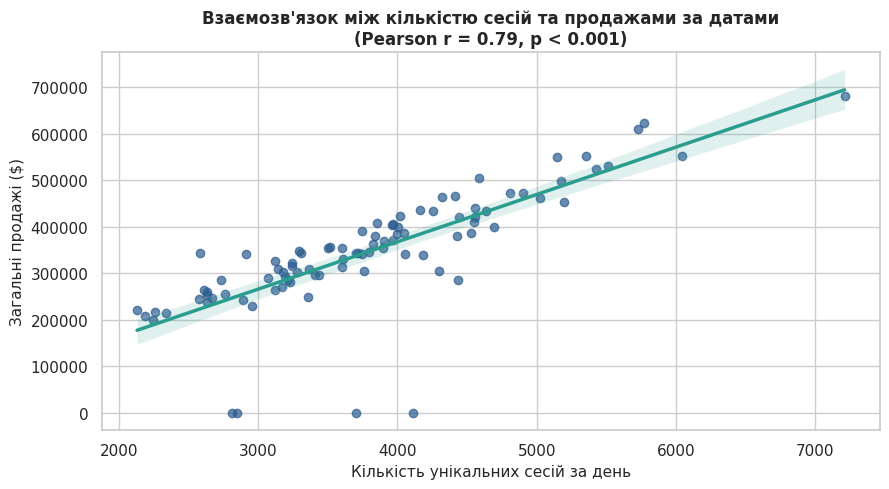

In [ ]:
from scipy import stats

# Сесії vs Продажі за датами

daily_metrics = df.groupby('session_date').agg(
    total_sessions=('ga_session_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

# Коефіцієнти кореляції та p-value
r_pearson, p_pearson = stats.pearsonr(daily_metrics['total_sessions'], daily_metrics['total_sales'])
r_spearman, p_spearman = stats.spearmanr(daily_metrics['total_sessions'], daily_metrics['total_sales'])

print("КОРЕЛЯЦІЯ: КІЛЬКІСТЬ СЕСІЙ VS ПРОДАЖІ ЗА ДАТАМИ")
print(f"Пірсон  (Pearson):  r = {r_pearson:.4f}, p-value = {p_pearson:.4e}")
print(f"Спірмен (Spearman): ρ = {r_spearman:.4f}, p-value = {p_spearman:.4e}")


# Візуалізація Scatter Plot
plt.figure(figsize=(9, 5))
sns.regplot(
    data=daily_metrics,
    x='total_sessions',
    y='total_sales',
    color='#2b5c8f',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'#2a9d8f', 'linewidth':2.5}
)
plt.title(f'Взаємозв\'язок між кількістю сесій та продажами за датами\n(Pearson r = {r_pearson:.2f}, p < 0.001)', fontsize=12, fontweight='bold')
plt.xlabel('Кількість унікальних сесій за день', fontsize=11)
plt.ylabel('Загальні продажі ($)', fontsize=11)
plt.tight_layout()
plt.show()



**Коефіцієнт Пірсона (0.7911)**: Свідчить про сильну позитивну лінійну залежність між кількістю відвідувань сайту за день та загальною виручкою.

**Коефіціент Спірмена (0.8653)**: Показує ще сильніший монотонний зв'язок.

Оскільки значення **p-value** набагато менші за стандартний поріг значущості, виявлений зв'язок є статистично значущим.



КОРЕЛЯЦІЯ ПРОДАЖІВ МІЖ TOP-3 КОНТИНЕНТАМИ (Americas, Asia, Europe)


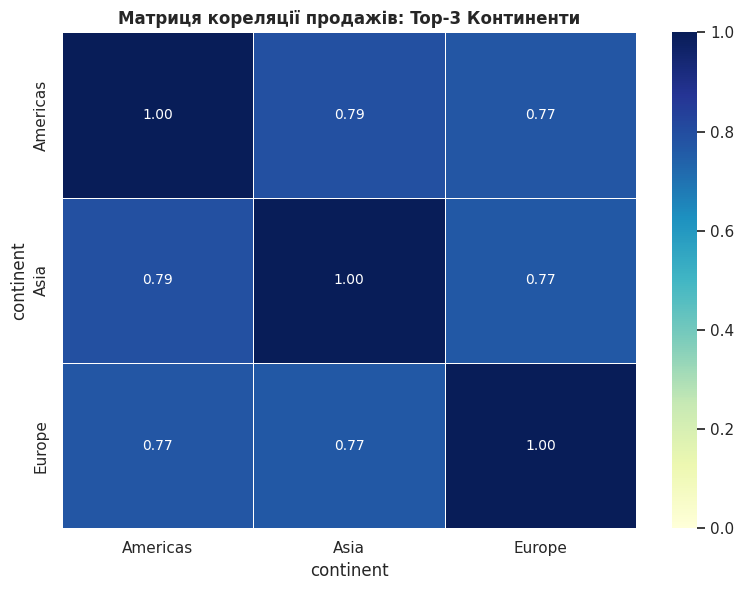

In [ ]:
# Кореляція продажів між Top-3 континентами

top_3_continents = df.groupby('continent')['price'].sum().nlargest(3).index.tolist()
cont_daily = df[df['continent'].isin(top_3_continents)].groupby(['session_date', 'continent'])['price'].sum().unstack().fillna(0)

print(f"КОРЕЛЯЦІЯ ПРОДАЖІВ МІЖ TOP-3 КОНТИНЕНТАМИ ({', '.join(top_3_continents)})")
corr_cont, p_cont = analyze_correlation_matrix(cont_daily, 'Top-3 Континенти')

Усі **коефіцієнти кореляції Пірсона** (r = 0.77 - 0.79) є статистично значущими.

**Високий рівень кореляції** між усіма трьома континентами пояснюється глобальною тижневою сезонністю та глобальними маркетинговими кампаніями (зокрема «Чорною п'ятницею» наприкінці листопада та грудневими святковими розпродажами).

КОРЕЛЯЦІЯ ПРОДАЖІВ МІЖ TOP-4 КАНАЛАМИ ТРАФІКУ


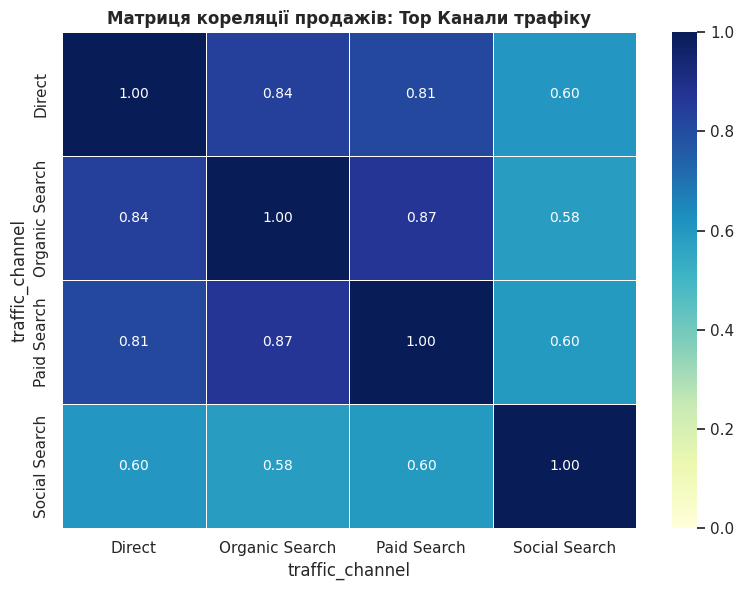

In [ ]:
# Кореляція продажів між Top-4 каналами трафіку

top_channels = df.groupby('traffic_channel')['price'].sum().nlargest(4).index.tolist()
channel_daily = df[df['traffic_channel'].isin(top_channels)].groupby(['session_date', 'traffic_channel'])['price'].sum().unstack().fillna(0)

print(f"КОРЕЛЯЦІЯ ПРОДАЖІВ МІЖ TOP-4 КАНАЛАМИ ТРАФІКУ")
corr_chan, p_chan = analyze_correlation_matrix(channel_daily, 'Top Канали трафіку')


**Organic Search та Paid Search (r = 0.87)**: Демонструють найвищий рівень позитивної кореляції серед усіх каналів. Динаміка продажів через платний та органічний пошук змінюється практично ідентично.   

**Direct та Organic Search (r = 0.84) / Direct та Paid Search (r = 0.81)**: Показують сильний позитивний зв'язок. Прямі заходи на сайт інтенсивно зростають разом із пошуковою активністю користувачів.   

**Social Search (r = 0.58 - 0.60)**: Демонструє помірну позитивну кореляцію з усіма іншими каналами. Динаміка із соцмереж також повторює загальний тренд, але має власні додаткові сплески активності.   

Усі коефіцієнти кореляції є статистично значущими.

КОРЕЛЯЦІЯ ПРОДАЖІВ МІЖ TOP-5 КАТЕГОРІЯМИ ТОВАРІВ


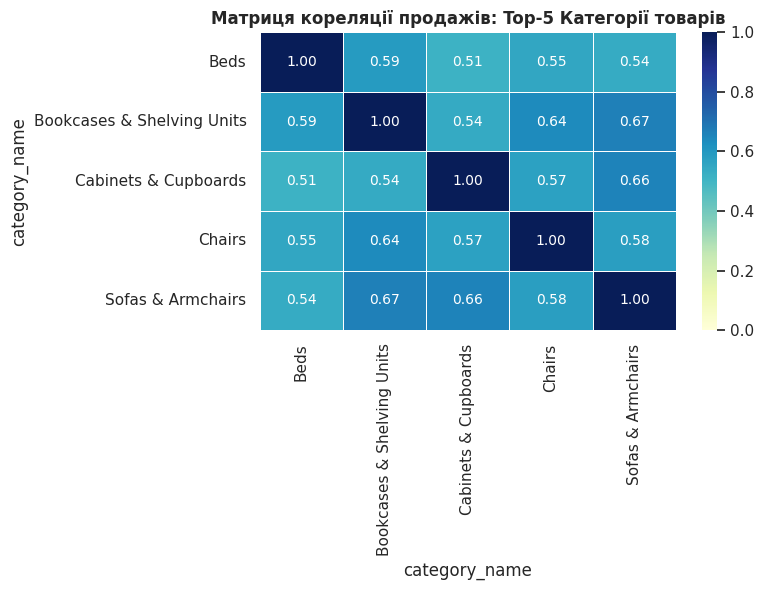

In [ ]:
# Кореляція продажів між Top-5 категоріями товарів

top_5_cats = df.groupby('category_name')['price'].sum().nlargest(5).index.tolist()
cat_daily = df[df['category_name'].isin(top_5_cats)].groupby(['session_date', 'category_name'])['price'].sum().unstack().fillna(0)

print(f"КОРЕЛЯЦІЯ ПРОДАЖІВ МІЖ TOP-5 КАТЕГОРІЯМИ ТОВАРІВ")
corr_cat, p_cat = analyze_correlation_matrix(cat_daily, 'Top-5 Категорії товарів')

**Bookcases & Shelving Units та Sofas & Armchairs (r = 0.67)**: Демонструють найвищий рівень позитивної кореляції серед усіх пар категорій.   

**Cabinets & Cupboards та Sofas & Armchairs (r = 0.66) / Bookcases & Shelving Units та Chairs (r = 0.64)**: Показують стійкий помірно-високий позитивний зв'язок.   

**Beds (r = 0.51 - 0.59)**: Демонструє найменшу, але все ще помірну позитивну кореляцію з іншими категоріями.   

Усі коефіцієнти кореляції є статистично значущими.



1. ОПИСАЛЬНІ СТАТИСТИКИ СЕРЕДНЬОГО ЧЕКА (AOV)


,device_clean,AOV,Median_Check,Std_Dev,Total_Orders,Total_Revenue
0,Desktop,957.47,445.0,1316.64,19702,18864039.0
1,Mobile,944.42,435.0,1315.51,13113,12384225.8


2. РЕЗУЛЬТАТИ ПЕРЕВІРКИ СТАТИСТИЧНИХ ГІПОТЕЗ
• T-тест (Welch's t-test)  : t = 0.8795 | p-value = 3.7911e-01
• Тест Манна-Уїтні (U-test): U = 130361108.50 | p-value = 1.5860e-01
-> ВИСНОВОК: Статистично значущої різниці у середньому чеку не виявлено.



/tmp/ipykernel_1028/3101439490.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
/tmp/ipykernel_1028/3101439490.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1028/3101439490.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


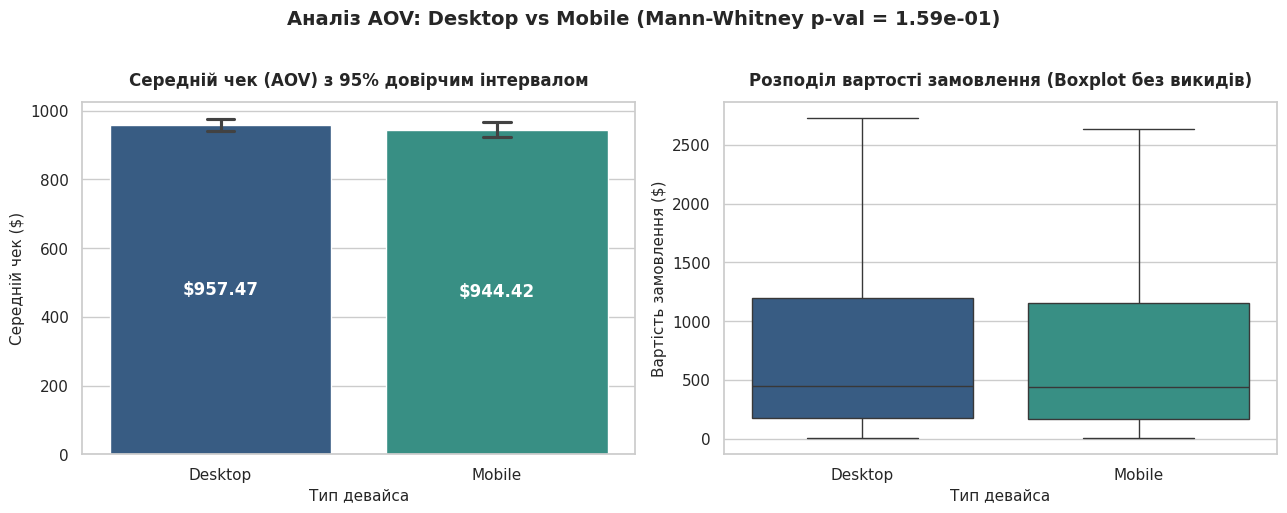

In [ ]:
# Анализ середнього чека за типом девайса (Desktop vs Mobile)
# 1. Фільтрація лише транзакцій з ціною та ключовими девайсами
sales_devices = df.dropna(subset=['price', 'device']).copy()
sales_devices['device_clean'] = sales_devices['device'].str.capitalize()

# Відбираємо лише Desktop та Mobile
df_filtered = sales_devices[sales_devices['device_clean'].isin(['Desktop', 'Mobile'])]

# 2. Розрахунок описальних статистик (AOV, Медіана, Std, Кількість)
aov_stats = df_filtered.groupby('device_clean')['price'].agg(
    AOV=('mean'),
    Median_Check=('median'),
    Std_Dev=('std'),
    Total_Orders=('count'),
    Total_Revenue=('sum')
).reset_index()

print("1. ОПИСАЛЬНІ СТАТИСТИКИ СЕРЕДНЬОГО ЧЕКА (AOV)")
display(aov_stats.round(2))

# 3. Статистичне тестування гіпотез
desktop_prices = df_filtered[df_filtered['device_clean'] == 'Desktop']['price']
mobile_prices = df_filtered[df_filtered['device_clean'] == 'Mobile']['price']

# Двовибірковий t-тест (Student's t-test)
t_stat, p_val_t = stats.ttest_ind(desktop_prices, mobile_prices, equal_var=False)

# Непараметричний тест Манна-Уїтні (Mann-Whitney U)
u_stat, p_val_u = stats.mannwhitneyu(desktop_prices, mobile_prices, alternative='two-sided')

print("2. РЕЗУЛЬТАТИ ПЕРЕВІРКИ СТАТИСТИЧНИХ ГІПОТЕЗ")
print(f"• T-тест (Welch's t-test)  : t = {t_stat:.4f} | p-value = {p_val_t:.4e}")
print(f"• Тест Манна-Уїтні (U-test): U = {u_stat:.2f} | p-value = {p_val_u:.4e}")

if p_val_u < 0.05:
    print("-> ВИСНОВОК: Різниця в середньому чеку між Desktop та Mobile є СТАТИСТИЧНО ЗНАЧУЩОЮ (p < 0.05).")
else:
    print("-> ВИСНОВОК: Статистично значущої різниці у середньому чеку не виявлено.")
print("="*70 + "\n")

# 4. Візуалізація
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Графік 1
sns.barplot(
    data=df_filtered,
    x='device_clean',
    y='price',
    palette=['#2b5c8f', '#2a9d8f'],
    ci=95,
    capsize=0.1,
    ax=ax1
)
ax1.set_title('Середній чек (AOV) з 95% довірчим інтервалом', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Тип девайса', fontsize=11)
ax1.set_ylabel('Середній чек ($)', fontsize=11)

# Додаємо підписи значень
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'${height:.2f}',
                 (p.get_x() + p.get_width() / 2., height / 2),
                 ha='center', va='center', fontsize=12, color='white', fontweight='bold')

# Графік 2:
sns.boxplot(
    data=df_filtered,
    x='device_clean',
    y='price',
    palette=['#2b5c8f', '#2a9d8f'],
    showfliers=False,
    ax=ax2
)
ax2.set_title('Розподіл вартості замовлення (Boxplot без викидів)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Тип девайса', fontsize=11)
ax2.set_ylabel('Вартість замовлення ($)', fontsize=11)

plt.suptitle(f'Аналіз AOV: Desktop vs Mobile (Mann-Whitney p-val = {p_val_u:.2e})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Користувачі купують товари аналогічної вартості незалежно від пристрою (мобільний чи десктоп).

# **Статистичний аналіз відмінностей між групами**

1. ПЕРЕВІРКА РОЗПОДІЛУ НА НОРМАЛЬНІСТЬ (Shapiro-Wilk Test)
• Зареєстровані користувачі : W = 0.9792 | p-value = 1.4817e-01
• Незареєстровані (Guest)   : W = 0.9488 | p-value = 1.2185e-03
Нормальність збережена: False
2. СТАТИСТИЧНИЙ ТЕСТ ПОРІВНЯННЯ ВИБІРОК (Wilcoxon Signed-Rank Test)
• Статистика тесту: 0.0000
• p-value         : 3.7320e-16
-> ВИСНОВОК: Різниця в щоденних продажах між зареєстрованими та гостьовими користувачами є статистично значущою.


/tmp/ipykernel_1028/2621054748.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


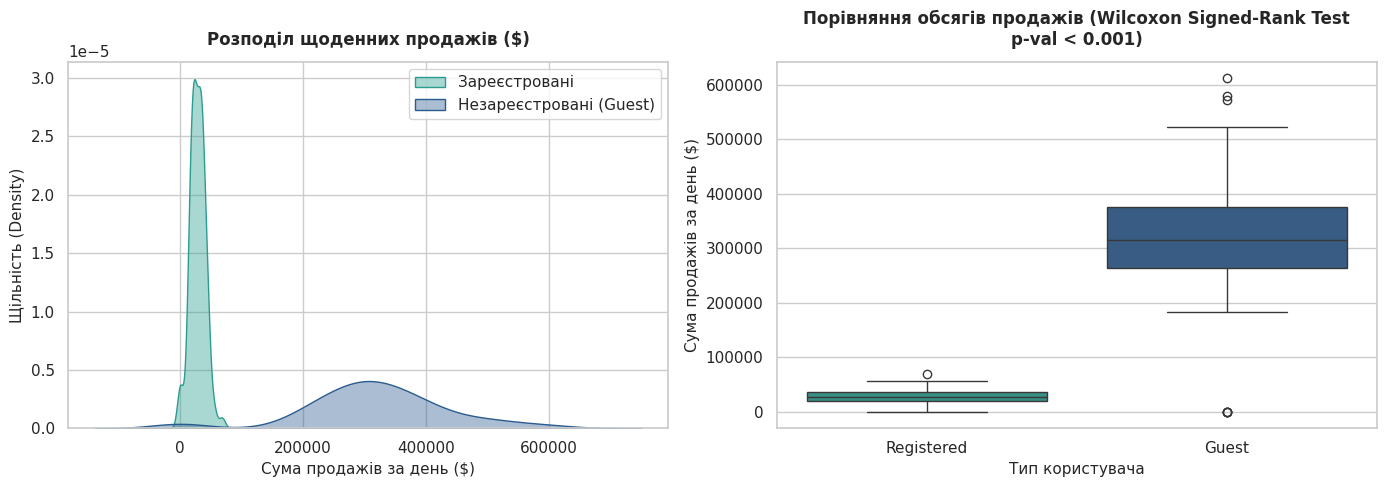

In [ ]:
# 1. Розділення та агрегація даних за датами
daily_sales_registered = (
    df[df['user_id'].notnull()]
    .groupby('session_date')['price']
    .sum()
    .rename('Registered')
)

daily_sales_guest = (
    df[df['user_id'].isnull()]
    .groupby('session_date')['price']
    .sum()
    .rename('Guest')
)

# Об'єднання
daily_user_sales = pd.concat([daily_sales_registered, daily_sales_guest], axis=1).fillna(0)

# 2. Перевірка розподілу даних на нормальність (Shapiro-Wilk Test)
stat_reg, p_reg = stats.shapiro(daily_user_sales['Registered'])
stat_gst, p_gst = stats.shapiro(daily_user_sales['Guest'])

print("1. ПЕРЕВІРКА РОЗПОДІЛУ НА НОРМАЛЬНІСТЬ (Shapiro-Wilk Test)")
print(f"• Зареєстровані користувачі : W = {stat_reg:.4f} | p-value = {p_reg:.4e}")
print(f"• Незареєстровані (Guest)   : W = {stat_gst:.4f} | p-value = {p_gst:.4e}")

# Перевірка умови нормальності (якщо p < 0.05, розподіл відхиляється від нормального)
is_normal = (p_reg >= 0.05) and (p_gst >= 0.05)
print(f"Нормальність збережена: {is_normal}")


# 3. Проведення тесту

if is_normal:
    stat_test, p_val_test = stats.ttest_rel(daily_user_sales['Registered'], daily_user_sales['Guest'])
    test_name = "Paired t-test"
else:
    stat_test, p_val_test = stats.wilcoxon(daily_user_sales['Registered'], daily_user_sales['Guest'])
    test_name = "Wilcoxon Signed-Rank Test"

print(f"2. СТАТИСТИЧНИЙ ТЕСТ ПОРІВНЯННЯ ВИБІРОК ({test_name})")
print(f"• Статистика тесту: {stat_test:.4f}")
print(f"• p-value         : {p_val_test:.4e}")

if p_val_test < 0.05:
    print("-> ВИСНОВОК: Різниця в щоденних продажах між зареєстрованими та гостьовими користувачами є статистично значущою.")
else:
    print("-> ВИСНОВОК: Статистично значущої різниці не виявлено.")

# 4. Побудова візуалізацій
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1
sns.kdeplot(data=daily_user_sales['Registered'], label='Зареєстровані', color='#2a9d8f', fill=True, alpha=0.4, ax=ax1)
sns.kdeplot(data=daily_user_sales['Guest'], label='Незареєстровані (Guest)', color='#2b5c8f', fill=True, alpha=0.4, ax=ax1)
ax1.set_title('Розподіл щоденних продажів ($)', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Сума продажів за день ($)', fontsize=11)
ax1.set_ylabel('Щільність (Density)', fontsize=11)
ax1.legend(loc='upper right')

# Графік 2
sns.boxplot(
    data=daily_user_sales.melt(var_name='User_Type', value_name='Daily_Sales'),
    x='User_Type',
    y='Daily_Sales',
    palette=['#2a9d8f', '#2b5c8f'],
    ax=ax2
)
ax2.set_title(f'Порівняння обсягів продажів ({test_name}\np-val < 0.001)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Тип користувача', fontsize=11)
ax2.set_ylabel('Сума продажів за день ($)', fontsize=11)

plt.tight_layout()
plt.show()

Понад 90% щоденного доходу магазину забезпечують користувачі без облікового запису. Це свідчить про високу ефективність Top of Funnel, але водночас підкреслює проблему зі збереженням та утриманням (Retention) клієнтів.

1. ОПИСОВА СТАТИСТИКА КІЛЬКОСТІ СЕСІЙ ЗА ДЕНЬ


,Середнє,Cт. відхилення,Медіана,Мінімум,Максимум
traffic_channel,,,,,
Organic Search,1352.45,336.57,1329.0,733.0,2589.0
Paid Search,1025.45,254.42,989.0,578.0,1959.0
Direct,884.59,220.23,869.5,481.0,1668.0
Social Search,303.41,88.13,308.0,137.0,561.0
Undefined,233.51,83.63,229.0,86.0,435.0


2. ПЕРЕВІРКА НА НОРМАЛЬНІСТЬ (Shapiro-Wilk Test)
• Organic Search      : W = 0.9641 | p-value = 1.2272e-02
• Paid Search         : W = 0.9633 | p-value = 1.0833e-02
• Direct              : W = 0.9704 | p-value = 3.4279e-02
• Social Search       : W = 0.9789 | p-value = 1.4127e-01
• Undefined           : W = 0.9732 | p-value = 5.4565e-02
3. СТАТИСТИЧНИЙ ТЕСТ ПОРІВНЯННЯ ГРУП (Kruskal-Wallis Test)
• Статистика тесту: 368.9806
• p-value         : 1.3970e-78
-> ВИСНОВОК: Відмінності у кількості сесій між каналами трафіку є статистично значущими.



/tmp/ipykernel_1028/655442100.py:53: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
/tmp/ipykernel_1028/655442100.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1028/655442100.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


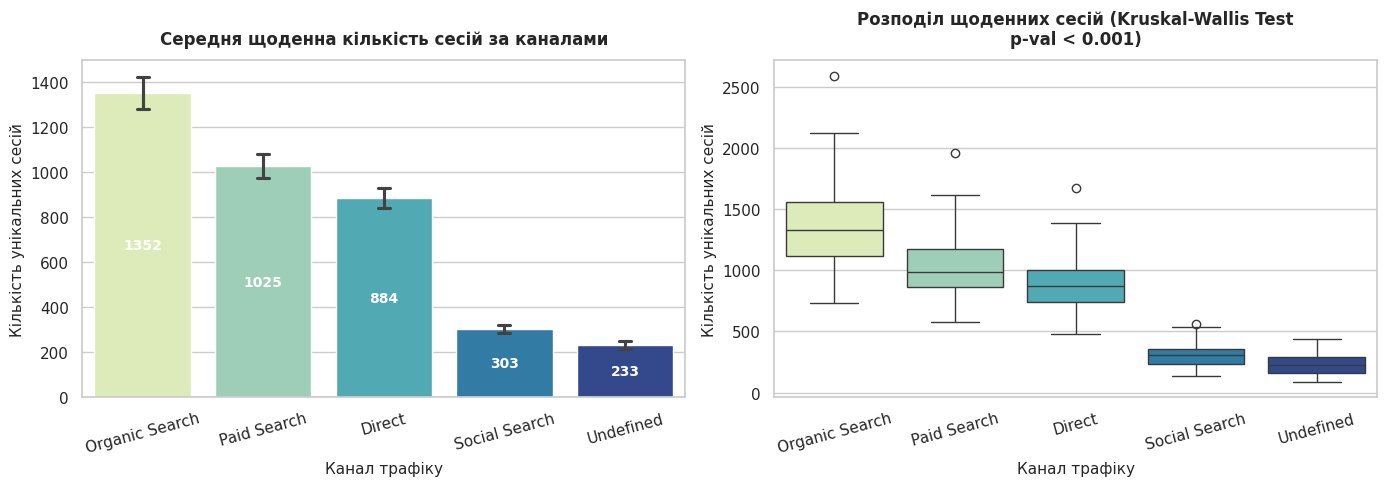

In [ ]:
# 1. Кількість сесій за датами та каналами трафіку
daily_sessions_by_channel = (
    df.groupby(['session_date', 'traffic_channel'])['ga_session_id']
    .nunique()
    .unstack(fill_value=0)
)

# Top-канали
top_channels = daily_sessions_by_channel.sum().nlargest(5).index.tolist()
daily_sessions = daily_sessions_by_channel[top_channels]

# 2. Описова статистика
print("1. ОПИСОВА СТАТИСТИКА КІЛЬКОСТІ СЕСІЙ ЗА ДЕНЬ")
stats_summary = daily_sessions.agg(['mean', 'std', 'median', 'min', 'max']).T
stats_summary.columns = ['Середнє', 'Cт. відхилення', 'Медіана', 'Мінімум', 'Максимум']
display(stats_summary.round(2))


# 3. Перевірка нормальності розподілу (Shapiro-Wilk Test)
print("2. ПЕРЕВІРКА НА НОРМАЛЬНІСТЬ (Shapiro-Wilk Test)")
is_all_normal = True
for col in daily_sessions.columns:
    stat_sh, p_sh = stats.shapiro(daily_sessions[col])
    print(f"• {col:<20}: W = {stat_sh:.4f} | p-value = {p_sh:.4e}")
    if p_sh < 0.05:
        is_all_normal = False



# 4. Проведення статистичного тесту

if is_all_normal:
    stat_test, p_val_test = stats.f_oneway(*[daily_sessions[col] for col in daily_sessions.columns])
    test_name = "One-Way ANOVA"
else:
    stat_test, p_val_test = stats.kruskal(*[daily_sessions[col] for col in daily_sessions.columns])
    test_name = "Kruskal-Wallis Test"

print(f"3. СТАТИСТИЧНИЙ ТЕСТ ПОРІВНЯННЯ ГРУП ({test_name})")
print(f"• Статистика тесту: {stat_test:.4f}")
print(f"• p-value         : {p_val_test:.4e}")

if p_val_test < 0.05:
    print("-> ВИСНОВОК: Відмінності у кількості сесій між каналами трафіку є статистично значущими.")
else:
    print("-> ВИСНОВОК: Статистично значущих відмінностей між каналами не виявлено.")
print("="*70 + "\n")

# 5. Візуалізація
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1
sns.barplot(
    data=daily_sessions.melt(var_name='Channel', value_name='Sessions'),
    x='Channel',
    y='Sessions',
    palette='YlGnBu',
    ci=95,
    capsize=0.1,
    ax=ax1
)
ax1.set_title('Середня щоденна кількість сесій за каналами', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Канал трафіку', fontsize=11)
ax1.set_ylabel('Кількість унікальних сесій', fontsize=11)
ax1.tick_params(axis='x', rotation=15)

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}',
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# Графік 2
sns.boxplot(
    data=daily_sessions.melt(var_name='Channel', value_name='Sessions'),
    x='Channel',
    y='Sessions',
    palette='YlGnBu',
    ax=ax2
)
ax2.set_title(f'Розподіл щоденних сесій ({test_name}\np-val < 0.001)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Канал трафіку', fontsize=11)
ax2.set_ylabel('Кількість унікальних сесій', fontsize=11)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Органічний пошук та платна реклама** формують основний каркас відвідуваності платформи.   

Низькі показники **Social Search** можуть свідчити про те, що канал SMM наразі недоінвестований або виконує лише допоміжну функцію воронки.

1. ВХІДНІ ДАНІ ТА ЧАСТКИ ОРГАНИЧНОГО ТРАФІКУ


,continent,organic_sessions,total_sessions,organic_share,organic_share_pct
0,Americas,68671,193179,0.3555,35.5479
1,Europe,23195,65135,0.3561,35.6107




2. СТАТИСТИЧНЕ ТЕСТУВАННЯ ГІПОТЕЗИ (Z-test & Chi-Square)
• Z-статистика           : -0.2895
• p-value (Z-test)       : 7.7219e-01
• Chi2-статистика        : 0.0811
• p-value (Chi2-test)    : 7.7581e-01

-> ВИСНОВОК: Статистично значущої різниці у частці органічного трафіку не виявлено.



/tmp/ipykernel_1028/1646221198.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


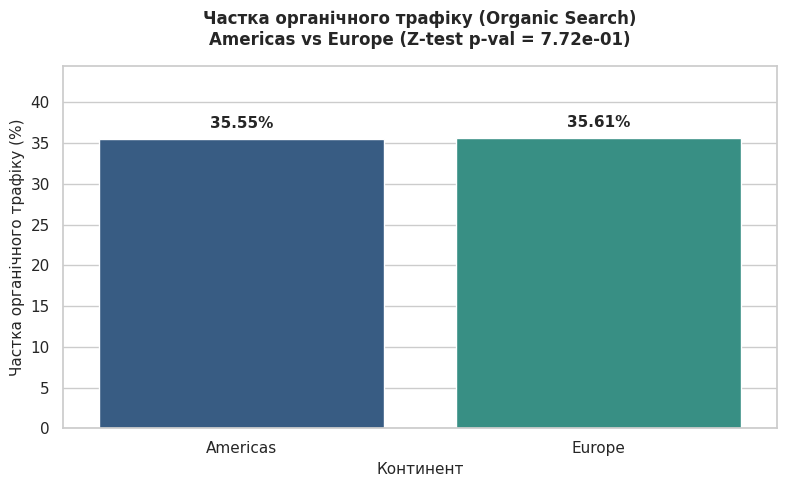

In [ ]:
# 1. Фільтрація трафіку для Americas та Europe
df_geo = df[df['continent'].isin(['Americas', 'Europe'])].dropna(subset=['traffic_channel']).copy()

# Створюємо бінарний прапорець органічного трафіку
df_geo['is_organic'] = (df_geo['traffic_channel'] == 'Organic Search').astype(int)

# 2. Кількість успіхів та загальний розмір вибірки
summary_geo = df_geo.groupby('continent').agg(
    organic_sessions=('is_organic', 'sum'),
    total_sessions=('is_organic', 'count')
).reset_index()

summary_geo['organic_share'] = summary_geo['organic_sessions'] / summary_geo['total_sessions']
summary_geo['organic_share_pct'] = summary_geo['organic_share'] * 100

print("1. ВХІДНІ ДАНІ ТА ЧАСТКИ ОРГАНИЧНОГО ТРАФІКУ")
display(summary_geo.round(4))
print("\n" + "="*70 + "\n")

# 3. Статистичний тест: Z-test для двох пропорцій
count = summary_geo['organic_sessions'].values
nobs = summary_geo['total_sessions'].values

# Проведення Z-тесту
z_stat, p_value_z = proportions_ztest(count, nobs)

# Альтернативна перевірка через Chi-Square Test
contingency_table = pd.crosstab(df_geo['continent'], df_geo['is_organic'])
chi2_stat, p_value_chi2, dof, _ = stats.chi2_contingency(contingency_table)

print("2. СТАТИСТИЧНЕ ТЕСТУВАННЯ ГІПОТЕЗИ (Z-test & Chi-Square)")
print(f"• Z-статистика           : {z_stat:.4f}")
print(f"• p-value (Z-test)       : {p_value_z:.4e}")
print(f"• Chi2-статистика        : {chi2_stat:.4f}")
print(f"• p-value (Chi2-test)    : {p_value_chi2:.4e}")

if p_value_z < 0.05:
    print("\n-> ВИСНОВОК: Частка органічного трафіку між Європою та Америкою відрізняється статистично значущо.")
else:
    print("\n-> ВИСНОВОК: Статистично значущої різниці у частці органічного трафіку не виявлено.")
print("="*70 + "\n")

# 4. Візуалізація
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=summary_geo,
    x='continent',
    y='organic_share_pct',
    palette=['#2b5c8f', '#2a9d8f']
)

plt.title(f'Частка органічного трафіку (Organic Search)\nAmericas vs Europe (Z-test p-val = {p_value_z:.2e})', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Континент', fontsize=11)
plt.ylabel('Частка органічного трафіку (%)', fontsize=11)
plt.ylim(0, max(summary_geo['organic_share_pct']) * 1.25)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                 (p.get_x() + p.get_width() / 2., height + 1),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Структура джерел залучення користувачів у Європі та Америці є практично ідентичною — в обох регіонах **Organic Search** стабільно формує трохи більше трени від усіх відвідувань сайту.